<a id="top"></a>

# Table of Contents

Overview of Step 1 checks on `clean_data` to guide later cleaning and analysis.

1. [Article Length](#1-article-length)  
   ∘ [1.1 Bar chart of article length](#11-bar-chart-of-article-length)  
   ∘ [1.2 Consistency check: `length` vs. body word count](#12-consistency-check-length-vs-body-word-count)  

2. [Sections Analysis](#2-sections-analysis)  
   ∘ [2.1 Sections — Step 1 (de-noise)](#21-sections-analysis-step1)  
   ∘ [2.1 Sections — Step 1 — Findings](#21-sections-analysis-step1-findings)

---

<a id="1-article-length"></a>
# 1. Article Length

In [32]:
import pandas as pd

df = pd.read_pickle("../../data/processed/cleaned_articles.pkl")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nHead:")
print(df.head(3))

Shape: (41148, 12)
Columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw']

Head:
                                               title        publisher  \
0  A Well-Documented Childhood. A Very Private Life.   New York Times   
1  These were the big stories in arts and culture...  Other publisher   
2                    She Exalted The Beauty Of Dance   New York Times   

         date                                            section  \
0  2024-12-31         Section A; Column 0; National Desk; Pg. 16   
1  2024-12-31                                       WHAT TO KNOW   
2  2024-12-31  Section C; Column 0; The Arts/Cultural Desk; P...   

                                                body  length  letters_flag  \
0  Jimmy Carter's daughter had an extraordinary a...    1209         False   
1  The arts in Dayton continued to thrive in 2024...    3345         False   
2  Sh

<a id="11-bar-chart-of-article-length"></a>
### 1.1 Bar chart of article length
[↰ Return to Top](#top)

> **Context.** Visualize how article lengths are distributed to spot the main range and any long tail.

**Inputs:** `length` (string) → extract digits via regex and convert to numeric `length_num`.  

**Method:**  
- Compute the **99th percentile (P99)** of `length_num` and **round up to the nearest 50** as the clipping cap `cap`.  
- Use **adaptive bin width**: start at **50** and keep **doubling** (50→100→200→400→…) until the histogram has **≤ 30 bars**.  

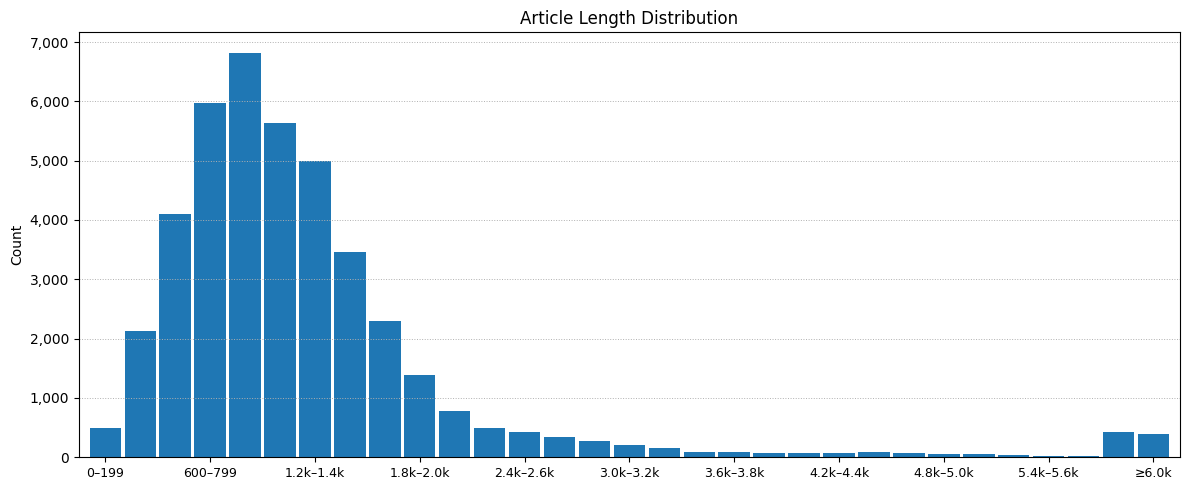

Note: 394 articles in the overflow bin (length ≥ 5,950). Bin size = 200.


In [6]:
# Step 1.1 · Bar chart of article length 
import numpy as np, pandas as pd, matplotlib.pyplot as plt, re
from matplotlib.ticker import FuncFormatter

# reuse df; load if missing
try:
    df
except NameError:
    df = pd.read_pickle("../data/processed/cleaned_articles.pkl").copy()

# ensure numeric length
if "length_num" not in df.columns:
    df["length_num"] = pd.to_numeric(
        df["length"].astype(str).str.extract(r"(\d+)")[0], errors="coerce"
    )

x = df["length_num"].dropna().astype(int)
if len(x) == 0:
    print("No numeric lengths to plot.")
else:
    # 1) clip long tail at 99th percentile (round up to nearest 50)
    cap = int(np.ceil(np.percentile(x, 99) / 50.0) * 50)

    # 2) adaptive bin so bars <= 30~35
    bin_size = 50
    while int(np.ceil(cap / bin_size)) > 30:
        bin_size *= 2

    # 3) counts + overflow (>= cap)
    bins = np.arange(0, cap + bin_size, bin_size)
    clipped = x.clip(upper=cap - 1)
    cats = pd.cut(clipped, bins=bins, include_lowest=True, right=True)
    counts = cats.value_counts().sort_index()
    overflow = int((x >= cap).sum())

    # labels helper -> use k-abbrev (e.g., 1.2k)
    def fmt_k(n): 
        return f"{n/1000:.1f}k" if n >= 1000 else f"{n}"
    labels = [f"{fmt_k(l)}–{fmt_k(r-1)}" for l, r in zip(bins[:-1], bins[1:])]
    if overflow > 0:
        counts = pd.concat([counts, pd.Series([overflow], index=[f"≥{fmt_k(cap)}"])])
        labels.append(f"≥{fmt_k(cap)}")

    # 4) draw with sparse ticks
    idx = np.arange(len(counts))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(idx, counts.values, width=0.9)

    ax.set_title("Article Length Distribution")
    ax.set_ylabel("Count")

    # show ~8–10 x-tick labels max
    n_labels = min(10, len(labels))
    step = max(1, len(labels) // n_labels)
    tick_idx = idx[::step]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([labels[i] for i in tick_idx], rotation=0, fontsize=9)

    # y as 1,000 separators + light grid
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v):,}"))
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7)
    plt.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    if overflow > 0:
        print(f"Note: {overflow:,} articles in the overflow bin (length ≥ {cap:,}). Bin size = {bin_size}.")

<a id="11-findings-article-length"></a>
#### Findings — 1.1 Article length *(bin = 200 words; cap = 5,950; overflow = 394)*
- The distribution is **right-skewed**, with a clear mode around **~800–1,200 words** (the 800–999 and 1.0k–1.2k bins form the peak).
- **Very short pieces (<400 words)** are relatively uncommon; volumes ramp up quickly from **400** to **~1,200**.
- The **bulk of articles** fall in the **400–1,600** range, and the **vast majority** are **below 2,000 words**.
- Counts **decline steadily beyond ~3,200 words**, indicating a long but thin tail of long-form pieces.
- **Overflow (≥5,950 words): 394 articles (~≈1%)** are grouped into a single bin for readability.

[↰ Return to Top](#top)

<a id="12-consistency-check-length-vs-body-word-count"></a>
### 1.2 Consistency check: `length` vs. body word count
[↰ Return to Top](#top)

> **Context.** Sanity-check that the provided `length` aligns with the tokenized word count from `body`.

**Inputs:** `length_num` (parsed), `body` → `word_count`.  
**Method:** Compute relative error `|length_num − word_count| / word_count` and report the share within **±5%**.  
**Output:** Match rate + median absolute/relative differences; optionally print a few mismatched examples.


In [7]:
# Step 1.2 · Consistency check exactly as described (±5% + optional examples)
import re, numpy as np, pandas as pd

TOL = 0.05                 # ±5%
SHOW_EXAMPLE_ARTICLES = True

# Reuse df; load if missing
try:
    df
except NameError:
    df = pd.read_pickle("../data/processed/cleaned_articles.pkl").copy()

# Inputs: length_num (parsed), body -> word_count
if "length_num" not in df:
    df["length_num"] = pd.to_numeric(df["length"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")

rx = re.compile(r"\b\w+\b", flags=re.UNICODE)
df["word_count"] = df["body"].apply(lambda s: len(rx.findall(s)) if isinstance(s, str) else 0)

# Relative error |length_num - word_count| / word_count
mask = df["length_num"].notna() & (df["word_count"] > 0)
rel_diff = (df.loc[mask, "length_num"] - df.loc[mask, "word_count"]).abs() / df.loc[mask, "word_count"]
abs_diff = (df.loc[mask, "length_num"] - df.loc[mask, "word_count"]).abs()

# Report
print(f"Rows checked: {mask.sum():,}")
print(f"Share within ±5%: {rel_diff.le(TOL).mean():.1%}")
print(f"Median abs diff: {int(abs_diff.median())} words")
print(f"Median rel diff: {rel_diff.median():.1%}")

#print a few mismatched examples
if SHOW_EXAMPLE_ARTICLES:
    examples = (
        df.loc[mask, ["title","section","length","length_num","word_count"]]
          .assign(rel_diff=rel_diff.values)
          .query("rel_diff > @TOL")
          .sort_values("rel_diff", ascending=False)
          .head(5)
    )
    if len(examples):
        with pd.option_context("display.max_colwidth", 120):
            print("\nExamples of mismatches (>±5%):")
            print(examples.to_string(index=False))

Rows checked: 41,148
Share within ±5%: 52.9%
Median abs diff: 48 words
Median rel diff: 4.7%

Examples of mismatches (>±5%):
                                                                                                                                                    title                                                 section  length  length_num  word_count  rel_diff
                                                                                                                                                WORLD CUP                              SPORTS; Pg. 1B; Sportsline    1302        1302         405  2.214815
                                                                                                                                       GRAFFITI ISN'T ART               EDITORIAL; LETTERS TO THE EDITOR; Pg. B-6     625         625         233  1.682403
                                                                                                                       

<a id="12-consistency-check-length-vs-body-word-count-findings"></a>
#### Findings — 1.2 Consistency check: `length` vs. body word count
- **Rows checked:** 41,148  
- **Share within ±5%:** **52.9%**  
- **Median absolute difference:** **48 words**  
- **Median relative difference:** **4.7%**

**Interpretation.** About half of the records agree closely (±5%). The typical gap is small (≈50 words / 4–5%), suggesting the two measures generally align. However, a non-trivial tail of mismatches remains.

**Patterns from top mismatches :**
- Cases where **`length_num` ≫ `word_count`** (e.g., 1302 vs 405; 625 vs 233; 1889 vs 756) likely indicate **partial/truncated bodies** or briefs/teasers captured in `body`.
- Cases where **`length_num` ≪ `word_count`** (e.g., 151 vs 1,219; 443 vs 3,042) suggest the **`length` field was misparsed or inconsistently defined** for some items (e.g., page codes like “Pg. H01” leaking digits into `length`, or publisher-specific length conventions).

<a id="2-sections-analysis"></a>
# 2. Sections Analysis
[↰ Return to Top](#top)


In [33]:
sections = (
    df["section"]
      .dropna()
      .astype(str)
      .str.strip()
      .loc[lambda s: s.ne("")]
    .unique()
)

for s in sorted(sections):
    print(s)

'Road less traveled'; Pg. 1G
,
.FOOD; Pg. D1
48 Hours; Pg. 6G
48 hours; Pg. 1G
; Inq Arts & Entertainment; Pg. 00
; Pg. A1
; Pg. A10
; Pg. A11
; Pg. A12
; Pg. A13
; Pg. A14
; Pg. A15
; Pg. A16
; Pg. A17
; Pg. A18
; Pg. A2
; Pg. A22
; Pg. A23
; Pg. A27
; Pg. A3
; Pg. A4
; Pg. A5
; Pg. A6
; Pg. A7
; Pg. A8
; Pg. A9
; Pg. AA1
; Pg. B1
; Pg. B2
; Pg. B3
; Pg. B4
; Pg. B5
; Pg. B6
; Pg. B7
; Pg. B8
; Pg. C3
; Pg. C5
; Pg. C6
; Pg. D1
; Pg. D12
; Pg. D15
; Pg. D2
; Pg. D3
; Pg. D4
; Pg. D5
; Pg. D7
; Pg. E1
; Pg. E2
; Pg. E8
; Pg. G1
; Pg. GO12
; Pg. GO15
; Pg. GO3
; Pg. GO5
; Pg. P8
; Pg. SA1
; Pg. SA2
; Pg. SA3
; Pg. SB1
; Pg. SB2
; Pg. SB4
; Pg. SB6
; Pg. SC1
; Pg. SC10
; Pg. SC16
; Pg. SC18
; Pg. SD1
; Pg. SE1
; Pg. SF10
; Pg. SF14
; Pg. SF18
; Pg. SF2
; Pg. SF3
; Pg. SF9
; Pg. SH2
; Pg. SPA1
; Pg. SPA10
; Pg. SPA5
; Pg. SPA6
; Pg. SPA7
; Pg. SPA8
; Pg. SPB10
; Pg. SPB4
; Pg. SPB5
; Pg. SPB6
; Pg. SPC6
; Pg. SPD6
; Pg. Z1
; Pg. Z2
; Pg. Z3
; Pg. Z4
; Pg. Z5
; Pg. Z6
; Pg. Z7
; Pg. Z8
; P

In [34]:
#Check for unique section names
from itertools import islice

sections_raw = df["section"].dropna().astype(str)

unique_raw = set(sections_raw)
print("Unique count (raw):", len(unique_raw))
list(islice(unique_raw, 20))  # show 20 samples

Unique count (raw): 12352


['CTI; Pg. 4',
 '',
 'Section SP; Column 0; Sports Desk; Pg. 2; HISTORYSOURCE',
 'Section B; Column 1; Metropolitan Desk; Pg. 2',
 'EDITORIAL; LETTERS TO THE EDITOR; Pg. B-4',
 '; Pg. A12',
 'NEWS; P-com Opinion; Pg. WEB',
 'Section A; Column 3; National Desk; Pg. 21',
 'Section 14CN; Column 0; Connecticut Weekly Desk; Pg. 9',
 'TIME OUT!; Pg. 25; On theater',
 'Section 1; ; Section 1;  Page 11;  Column 3;  Cultural Desk ; Column 3; ; Review',
 'BUSINESS; Pg. E-1',
 'LIFE; Pg. 14D',
 "Section 6; 'T'; Column 1; T: Women's Fashion Magazine; Pg. 142; THE GET",
 'Section 7; Page 42, Column 1; Book Review Desk',
 'Section 3; Page 10, Column 1; Financial Desk',
 'Section A; Column 0; Editorial Desk; Pg. 23; CHARLES M. BLOW',
 'Section A; Page 32, Column 1; National Desk; Text',
 'FEATURES FOOD; Pg. F01',
 'Section 7; Column 2; Book Review Desk; Pg. 16']

In [35]:
# Clean NBSP and extra spaces
sections_clean = (
    sections_raw
      .str.replace("\xa0", " ", regex=False)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

unique_clean = set(sections_clean)
print("Unique count (cleaned):", len(unique_clean))
list(islice(unique_clean, 20))  # show 20 samples after cleaning

Unique count (cleaned): 12055


['CTI; Pg. 4',
 '',
 'Section SP; Column 0; Sports Desk; Pg. 2; HISTORYSOURCE',
 'Section B; Column 1; Metropolitan Desk; Pg. 2',
 'EDITORIAL; LETTERS TO THE EDITOR; Pg. B-4',
 '; Pg. A12',
 'NEWS; P-com Opinion; Pg. WEB',
 'Section A; Column 3; National Desk; Pg. 21',
 'Section 14CN; Column 0; Connecticut Weekly Desk; Pg. 9',
 'TIME OUT!; Pg. 25; On theater',
 'BUSINESS; Pg. E-1',
 'LIFE; Pg. 14D',
 "Section 6; 'T'; Column 1; T: Women's Fashion Magazine; Pg. 142; THE GET",
 'Section 13; ; Section 13; Page 4; Column 2; The City Weekly Desk ; Column 2; ; Biography',
 'Section 7; Page 42, Column 1; Book Review Desk',
 'Section 3; Page 10, Column 1; Financial Desk',
 'Section A; Column 0; Editorial Desk; Pg. 23; CHARLES M. BLOW',
 'Section A; Page 32, Column 1; National Desk; Text',
 'Section 1; ; Section 1; Page 15; Column 4; National Desk ; Column 4; ; Biography',
 'FEATURES FOOD; Pg. F01']

In [36]:
import re

# Split on semicolon or slash
parts_series = sections_clean.apply(lambda x: re.split(r"[;/]", x))

# Flatten tokens
tokens = [
    t.strip()
    for parts in parts_series
    for t in parts
    if t and t.strip()
]

print("Total tokens:", len(tokens))
print("Unique tokens:", len(set(tokens)))
list(islice(set(tokens), 20))  # show 20 samples

Total tokens: 133460
Unique tokens: 4142


['ADELAIDE JOURNAL',
 'REAL ESTATE MARKETPLACE',
 'Pg. 9H',
 'GREENWOOD HEIGHTS JOURNAL',
 'DISTANT BROTHERS: Bridging a Divide',
 'Plain Talk',
 'Pg. T06',
 'REPLY ALL LETTERS',
 'UPSHOT',
 'RITES OF PASSAGE',
 'Inq Special Reports',
 'MEDIA MEMO',
 'Pg. 155',
 'WATCHING',
 'HAVENS',
 'Special report',
 'Page 20, Column 3',
 'HEARD OFF THE STREET',
 'Pg. RH3',
 'Pg. 6B']

In [37]:
from collections import Counter

counts = Counter(tokens)
df_section_token_freq = (
    pd.DataFrame(counts.items(), columns=["Section_Token", "Frequency"])
      .sort_values("Frequency", ascending=False)
      .reset_index(drop=True)
)

# Top 50 tokens
df_section_token_freq.head(50)

,Section_Token,Frequency
0,Column 0,9698
1,Section A,7814
2,Column 1,5885
3,National Desk,3369
4,Pg. 1,3159
5,NEWS,2650
6,Metropolitan Desk,2475
7,Section B,2362
8,Foreign Desk,2342
9,Section C,2189


<a id="21-sections-analysis-step1"></a>
### 2.1 Sections — Step 1 (de-noise)

**What we do now.** We strip obvious layout tokens (e.g., `Section A`, `Column 0`, `Pg. 1`, `Page A01`) from the raw `section` field and take the **first remaining token** as a provisional label `section_primary_v1`.


In [38]:
# Sections — Step 1: de-noise only (no synonym merging)
import re
import pandas as pd

# Load df if needed
try:
    df
except NameError:
    df = pd.read_pickle("../data/processed/cleaned_articles.pkl")

# De-noise -> provisional primary label
NOISE = re.compile(
    r"^(Section\s+[A-Z0-9]+|Column\s+\d+|Pg\.?\s*\w+|Page\s*\w+|[A-Z]|\d+)$",
    re.I
)

def primary_token_from_section(raw: str) -> str:
    """Return a provisional primary label by removing layout noise and taking the first surviving token."""
    if not isinstance(raw, str) or not raw.strip():
        return "Missing/Blank"
    s = raw.replace("\xa0", " ").strip()
    # split on semicolon or slash; don't split on comma to keep phrases like "Movies, Performing Arts"
    parts = [p.strip() for p in re.split(r"[;/]", s) if p and p.strip()]
    keep = [p for p in parts if not NOISE.match(p)]
    if not keep:
        return "Missing/Blank"
    return keep[0]

df["section_primary_v1"] = df["section"].apply(primary_token_from_section)

# Frequency table (top 30) and Missing/Blank at the bottom
vc = df["section_primary_v1"].value_counts(dropna=False)
tbl = (vc.to_frame("count")
         .assign(share=lambda d: (d["count"] / len(df) * 100).round(1))
         .reset_index()
         .rename(columns={"index": "section_primary_v1"}))

missing_share = float(
    tbl.loc[tbl["section_primary_v1"].eq("Missing/Blank"), "share"].values[0]
) if "Missing/Blank" in tbl["section_primary_v1"].values else 0.0

print(f"Unique primary labels (v1): {tbl['section_primary_v1'].nunique()}")
print(f"Missing/Blank share: {missing_share}%")

tbl_sorted = pd.concat([
    tbl.loc[~tbl["section_primary_v1"].eq("Missing/Blank")].head(30),
    tbl.loc[tbl["section_primary_v1"].eq("Missing/Blank")]
], ignore_index=True)

# Show the table
tbl_sorted


Unique primary labels (v1): 843
Missing/Blank share: 1.1%


,section_primary_v1,count,share
0,National Desk,2893,7.0
1,NEWS,2650,6.4
2,OPINION,2118,5.1
3,Metropolitan Desk,2106,5.1
4,Foreign Desk,1714,4.2
5,US,1408,3.4
6,Editorial Desk,1396,3.4
7,The Arts,1000,2.4
8,Book Review Desk,925,2.2
9,NATIONAL,828,2.0


<a id="21-sections-analysis-step1-findings"></a>
### 2.1 Sections — Step 1 — Findings

**Coverage.**  
- `section_primary_v1` unique labels: **843**  
- `Missing/Blank` share: **1.1%** → the raw `section` field is largely populated after de-noising.

**Top labels (illustrative shares):**  
- **National Desk (7.0%)**, **NEWS (6.4%)**, **OPINION (5.1%)**, **Metropolitan Desk (5.1%)**  
- **Foreign Desk (4.2%)**, **US (3.4%)**, **Editorial Desk (3.4%)**  
- **The Arts (2.4%)**, **Book Review Desk (2.2%)**  
- Other frequent variants include **NATIONAL (2.0%)**, **BUSINESS (2.0%)**, **Arts and Leisure Desk (1.8%)**, **LIFE (1.8%)**, **WORLD (1.7%)**, **Magazine Desk (1.4%)**.

**What this means.**  
- Step 1 successfully strips obvious layout noise while preserving meaningful editorial signals (e.g., *National/Metropolitan/Foreign/Book Review/Sports/Arts*).  
- The label set still contains **near-duplicates** due to publisher casing and phrasing differences (e.g., `Business` vs `BUSINESS`, `National Desk` vs `NATIONAL`, `Foreign Desk` vs `WORLD`).  
- A few residual artifacts remain (e.g., standalone **`Section`**; tokens with **trailing commas** such as `ARTS & ENTERTAINMENT,` or `EDITORIAL,`).

*Next (optional, not executed now):* if/when needed, introduce a small synonym map to collapse clear variants (e.g., `National Desk`/`NATIONAL` → *National*; `Business`/`BUSINESS`/`Financial Desk` → *Business*; `Foreign Desk`/`WORLD` → *World*; `The Arts`/`Arts and Leisure Desk` → *Arts & Culture*), then re-check coverage and shares.


<a id="21-sections-analysis-step1-findings"></a>
### 2.2 Sections — Step 2 — Clean Labels

<a id="22-sections-analysis-normalize"></a>
### 2.2 Sections — Case & trailing punctuation normalization 

**Goal.** Collapse near-duplicate labels that differ only by casing or stray trailing punctuation, without changing meaning.

**Method.**
- Replace non-breaking spaces and trim whitespace; collapse multiple spaces.
- Strip trailing punctuation (`, . ; : _ -`) from the end of the token (e.g., `EDITORIAL,` → `EDITORIAL`).
- Apply *smart* casing:
  - Title Case for regular words.
  - Preserve common acronyms as uppercase (`US`, `U.S.`, `UK`, `EU`, `NY`, `NYC`, `USA`).
  - Keep short all-caps acronyms (2–4 letters) as-is.

**Output.**
- New column: `section_primary_v1_norm`.
- Before/after unique counts to quantify reduction, plus a preview of groups where multiple originals collapsed into one normalized label.

**Notes.**
- This step is intentionally non-semantic: it does *not* merge synonyms (e.g., `Foreign Desk` vs `WORLD`).  
- After reviewing the reduction in unique labels, we can decide whether to proceed with light synonym merging as a separate step.


In [39]:
import re
import pandas as pd

# Ensure Step 1 exists
if "section_primary_v1" not in df.columns:
    raise RuntimeError("Please run Step 1 (de-noise) to create 'section_primary_v1' first.")

def normalize_case_and_tail(s: str) -> str:
    """Normalize whitespace/case and strip trailing punctuation, without semantic merging."""
    if not isinstance(s, str):
        return "Missing/Blank"
    # Replace NBSP, strip spaces
    t = s.replace("\xa0", " ").strip()
    if not t:
        return "Missing/Blank"
    # Remove trailing punctuation (keep core text)
    t = re.sub(r"[,\.;:_-]+$", "", t)  # e.g., "EDITORIAL," -> "EDITORIAL"
    t = re.sub(r"\s+", " ", t)         # collapse multiple spaces

    # Smart Title Case while preserving common acronyms like US/U.S./UK/EU/NY/NYC
    def smart_title_token(tok: str) -> str:
        if re.fullmatch(r"(U\.S\.|U\.K\.|E\.U\.)", tok, flags=re.I):
            return tok.upper()
        if re.fullmatch(r"(US|UK|EU|NY|NYC|USA)", tok, flags=re.I):
            return tok.upper()
        # Keep all-caps short acronyms (2–4 letters) as-is
        if re.fullmatch(r"[A-Z]{2,4}", tok):
            return tok
        return tok.title()

    # Split on spaces but keep them to re-join
    parts = re.split(r"(\s+)", t)
    parts = [smart_title_token(p) if p.strip() else p for p in parts]
    t = "".join(parts).strip()
    return t if t else "Missing/Blank"

# Apply normalization
df["section_primary_v1_norm"] = df["section_primary_v1"].apply(normalize_case_and_tail)

# Quick before/after summary
n_before = df["section_primary_v1"].nunique(dropna=False)
n_after  = df["section_primary_v1_norm"].nunique(dropna=False)

print(f"Unique labels — before (v1): {n_before}")
print(f"Unique labels — after  (v1_norm): {n_after}")
print(f"Reduction: {n_before - n_after} ({(n_before - n_after) / n_before:.1%})")

# Show top normalized labels
top_norm = (df["section_primary_v1_norm"]
              .value_counts()
              .to_frame("count")
              .assign(share=lambda d: (d["count"]/len(df)*100).round(1))
              .head(30))
display(top_norm)

# Inspect groups where multiple original variants collapsed to the same normalized label
collapsed = (df
    .groupby(["section_primary_v1_norm","section_primary_v1"])
    .size()
    .reset_index(name="count"))

multi_map = (collapsed
    .groupby("section_primary_v1_norm")["section_primary_v1"]
    .nunique()
    .reset_index(name="n_variants"))

multi_map = multi_map[multi_map["n_variants"] > 1].sort_values("n_variants", ascending=False).head(20)

print("\nExamples where multiple originals collapsed into one normalized label (top 20 by variant count):")
display(
    collapsed[collapsed["section_primary_v1_norm"].isin(multi_map["section_primary_v1_norm"])]
      .sort_values(["section_primary_v1_norm","count"], ascending=[True, False])
      .head(100)
)


Unique labels — before (v1): 843
Unique labels — after  (v1_norm): 790
Reduction: 53 (6.3%)


,count,share
section_primary_v1_norm,,
National Desk,2893,7.0
NEWS,2733,6.6
Opinion,2118,5.1
Metropolitan Desk,2106,5.1
Foreign Desk,1714,4.2
US,1408,3.4
Editorial Desk,1396,3.4
Business,1393,3.4
The Arts,1000,2.4



Examples where multiple originals collapsed into one normalized label (top 20 by variant count):


,section_primary_v1_norm,section_primary_v1,count
34,Business,BUSINESS,816
36,Business,Business,482
35,Business,"BUSINESS,",95
87,Entertainment,ENTERTAINMENT,72
88,Entertainment,"ENTERTAINMENT,",38
89,Entertainment,Entertainment,35
240,NEWS,NEWS,2650
241,NEWS,"NEWS,",58
242,NEWS,NEWS_,25
259,Neighbors,NEIGHBORS,47


In [40]:
# Print all unique normalized section labels (one per line), sorted A→Z (case-insensitive)
labels = (df["section_primary_v1_norm"]
          .dropna()
          .astype(str)
          .str.strip()
          .unique())

labels_sorted = sorted(labels, key=lambda s: s.lower())

print(f"Total unique labels: {len(labels_sorted)}\n")
for i, lab in enumerate(labels_sorted, 1):
    print(f"{i:>3}. {lab}")


Total unique labels: 790

  1. 'Road Less Traveled'
  2. 'T'
  3. .Food
  4. 48 Hours
  5. Active Dayton
  6. AD
  7. AGD
  8. ARTS
  9. ARTS & Entertainment
 10. Arts & Ideas
 11. Arts & Leisure Desk
 12. ARTS AND Entertainment
 13. ARTS And Entertainment
 14. Arts And Leisure Desk
 15. Arts\&Entertainment
 16. Asection
 17. AUTO
 18. AUTO PLUS
 19. Auto Showcase
 20. Automobiles
 21. Beavercreek Fairborn AND Xenia
 22. Bellbrook & Sugarcreek TWP
 23. BEN
 24. BIZ Ledger
 25. Bonus
 26. Book Review Desk
 27. Books
 28. Boston 2004
 29. Briefing
 30. Bruce Springsteen AT Lincoln Financial Field
 31. Budgets
 32. Business
 33. Business & Money
 34. Business Insider
 35. Business PAGE
 36. Business WIRE
 37. Business Xchange
 38. Cars
 39. Centerville & Washington TWP
 40. China
 41. Circuits
 42. CITY & Region
 43. Classified
 44. Classifieds
 45. Climate
 46. Comics
 47. Community
 48. Community Voices
 49. Congratulations Class OF 2013
 50. Connecticut
 51. Connecticut Weekly Desk
 52

In [41]:
# Sections — Step 1b: remove layout/page noise from v1_norm (no semantic merging)
import re
import numpy as np
import pandas as pd

LABEL_COL = "section_primary_v1_norm"  # from your previous step

def is_layout_noise(label: str) -> bool:
    """Return True for layout/page artifacts like 'Page 10, Column 2', 'Pg. A01', 'Section ...', etc."""
    if not isinstance(label, str) or not label.strip():
        return True
    t = label.strip()
    # strip surrounding quotes if any (e.g., Section 2')
    t = re.sub(r"^[\"'‘’“”]+|[\"'‘’“”]+$", "", t)

    patterns = [
        r"^Page\s+[A-Za-z0-9]+,\s*Column\s+\d+$",     # Page Z, Column 1 ; Page 10, Column 2
        r"^Page\s+\d+(,\s*Column\s+\d+)?$",           # Page 5, Column 3 ; Page 40
        r"^Pg\.?\s*[A-Za-z0-9-]+$",                   # Pg. A01 ; Pg. D-6 ; Pg F-8
        r"^Part\s+\d+.*$",                            # Part 1, Page ... ; Part 2 ...
        r"^Section\b.*$",                             # Section ; Section BR ; Section A<Pg >13 ; Section 2'
        r"^[A-Z]section$",                            # Asection, etc.
        r"^Front[-_ ]?Page$",                         # Front Page / Front-Page / Front_Page
        r"^Main(\s+News)?$",                          # Main ; Main News
        r"^(NULL|Null|NIL|Unsorted)$",                # NULL, NIL, Unsorted
    ]
    return any(re.match(p, t, flags=re.IGNORECASE) for p in patterns)

mask_noise = df[LABEL_COL].apply(is_layout_noise)
print("Layout-noise rows flagged:", int(mask_noise.sum()))

# Create cleaned column: send layout noise to Missing/Blank; keep others as-is
df["section_primary_v1_clean"] = np.where(mask_noise, "Missing/Blank", df[LABEL_COL])

# Before/after uniques
n_before = df[LABEL_COL].nunique(dropna=False)
n_after  = df["section_primary_v1_clean"].nunique(dropna=False)
print(f"Unique labels — before: {n_before}")
print(f"Unique labels — after : {n_after}")
print(f"Reduction: {n_before - n_after} ({(n_before - n_after)/n_before:.1%})")

# Preview: top labels converted to Missing/Blank
top_converted = (df.loc[mask_noise, LABEL_COL]
                   .value_counts()
                   .head(20))
print("\nTop converted-to-Missing labels:")
print(top_converted.to_string())

# Use this as the working column going forward
df["section_primary_cur"] = df["section_primary_v1_clean"]


Layout-noise rows flagged: 4116
Unique labels — before: 790
Unique labels — after : 412
Reduction: 378 (47.8%)

Top converted-to-Missing labels:
section_primary_v1_norm
Section              424
Part 1               294
Page 1, Column 1     214
Part 2               128
Page 1, Column 2     119
Page 3, Column 1     102
Asection              98
Page 9, Column 1      87
MAIN NEWS             84
Page 1, Column 3      81
Page 7, Column 1      62
Page 2, Column 3      61
Page 6, Column 1      61
Front_Page            60
Page 8, Column 1      54
Page 5, Column 1      54
Page 11, Column 1     52
Page 13, Column 1     52
Page 10, Column 1     52
Page 12, Column 1     48


<a id="22b-sections-remove-layout-noise-findings"></a>
### 2.2b Sections — Remove residual layout/page noise — Findings

**Rows flagged as layout noise:** **4,116 (~10% of all rows)**  
**Unique labels:** **790 → 412** (**−47.8%**)

**Top converted-to-Missing examples:** `Section`, `Part 1`, `Page 1, Column 1/2/3`, `Asection`, `Front_Page`, `MAIN NEWS`, etc.

**Why this matters.**  
Removing page/column/part markers collapses non-editorial artifacts without changing editorial semantics, giving a cleaner baseline for subsequent steps.

**Working column:** `section_primary_cur = section_primary_v1_clean`.  
An audit flag is kept as `section_is_layout_noise` for traceability.


In [42]:
# 1) Keep an audit flag for transparency
df["section_is_layout_noise"] = (df["section_primary_v1_clean"] == "Missing/Blank")

# 2) Use the cleaned label as the working column for downstream steps
df["section_primary_cur"] = df["section_primary_v1_clean"]

# 3) Quick summary after cleaning
summary = (df["section_primary_cur"]
           .value_counts(dropna=False)
           .to_frame("count")
           .assign(share=lambda d: (d["count"] / len(df) * 100).round(1)))
mb_share = float(summary["share"].get("Missing/Blank", 0.0))
print(f"Missing/Blank share after cleaning: {mb_share:.1f}")
summary.head(30)

Missing/Blank share after cleaning: 11.1


,count,share
section_primary_cur,,
Missing/Blank,4575,11.1
National Desk,2893,7.0
NEWS,2733,6.6
Opinion,2118,5.1
Metropolitan Desk,2106,5.1
Foreign Desk,1714,4.2
US,1408,3.4
Editorial Desk,1396,3.4
Business,1393,3.4


In [43]:
vc = df["section_primary_cur"].value_counts()
labels_sorted = sorted(vc.index, key=lambda s: (s == "Missing/Blank", s.lower()))

print(f"Total unique labels: {len(labels_sorted)}\n")
for i, lab in enumerate(labels_sorted, 1):
    print(f"{i:>3}. {lab} ({vc[lab]:,})")


Total unique labels: 412

  1. 'Road Less Traveled' (1)
  2. 'T' (16)
  3. .Food (1)
  4. 48 Hours (2)
  5. Active Dayton (5)
  6. AD (13)
  7. AGD (15)
  8. ARTS (440)
  9. ARTS & Entertainment (768)
 10. Arts & Ideas (33)
 11. Arts & Leisure Desk (99)
 12. ARTS AND Entertainment (28)
 13. ARTS And Entertainment (6)
 14. Arts And Leisure Desk (752)
 15. Arts\&Entertainment (2)
 16. AUTO (4)
 17. AUTO PLUS (2)
 18. Auto Showcase (3)
 19. Automobiles (13)
 20. Beavercreek Fairborn AND Xenia (1)
 21. Bellbrook & Sugarcreek TWP (1)
 22. BEN (2)
 23. BIZ Ledger (3)
 24. Bonus (8)
 25. Book Review Desk (925)
 26. Books (422)
 27. Boston 2004 (2)
 28. Briefing (198)
 29. Bruce Springsteen AT Lincoln Financial Field (1)
 30. Budgets (1)
 31. Business (1,393)
 32. Business & Money (1)
 33. Business Insider (5)
 34. Business PAGE (4)
 35. Business WIRE (36)
 36. Business Xchange (2)
 37. Cars (3)
 38. Centerville & Washington TWP (1)
 39. China (1)
 40. Circuits (5)
 41. CITY & Region (112)
 42

In [44]:
# Sections — Step 2a: safe synonym merges
import re
import pandas as pd

SRC = "section_primary_cur"  # current working column (v1_clean)
DST = "section_primary_v2"

assert SRC in df.columns, f"{SRC} not found. Set section_primary_cur first."

def canon_label(x: str) -> str:
    """Conservative merges only; avoid publisher-specific semantics."""
    if not isinstance(x, str) or not x.strip():
        return "Missing/Blank"
    t = re.sub(r"\s+", " ", x.strip())

    # ---- Desk -> base (clear one-to-one) ----
    desk_map = {
        r"^Editorial Desk$": "Editorial",
        r"^Book Review Desk$": "Books",
        r"^Magazine Desk$": "Magazine",
        r"^Style Desk$": "Style",
        r"^Sports Desk$": "Sports",
        r"^Travel Desk$": "Travel",
        r"^Real Estate Desk$": "Real Estate",
        r"^Week In Review Desk$": "Week in Review",
        r"^Sunday Review Desk$": "Sunday Review",
        r"^Long Island Weekly Desk$": "Long Island",
        r"^Connecticut Weekly Desk$": "Connecticut",
        r"^The City Weekly Desk$": "The City Weekly",
    }
    for pat, lab in desk_map.items():
        if re.fullmatch(pat, t, flags=re.I):
            return lab

    # ---- Obvious opinion/editorial synonyms ----
    if re.fullmatch(r"(OP\s?ED|OPED)(\s+PAGE)?", t, flags=re.I):
        return "Opinion"

    # ---- Normalize pure-casing words (not acronyms) ----
    if re.fullmatch(r"NEWS", t):  # only the exact all-caps word
        return "News"
    if re.fullmatch(r"LIFE", t):
        return "Life"
    if re.fullmatch(r"ARTS", t):  # keep 'The Arts' separate; only plain 'ARTS'
        return "Arts"

    # ---- Arts & Entertainment variants (formatting only) ----
    if re.fullmatch(r"Arts\s*&\s*Entertainment", t, flags=re.I):
        return "Arts & Entertainment"
    if re.fullmatch(r"ARTS\s*AND\s*Entertainment", t, flags=re.I):
        return "Arts & Entertainment"
    if re.fullmatch(r"ARTS\s*And\s*Entertainment", t, flags=re.I):
        return "Arts & Entertainment"
    if re.fullmatch(r"Arts\\&Entertainment", t):  # escaped ampersand variant
        return "Arts & Entertainment"

    # keep everything else as-is (we will handle bigger families later)
    return t

# Apply
df[DST] = df[SRC].apply(canon_label)

# Quick before/after uniques
n_before = df[SRC].nunique(dropna=False)
n_after  = df[DST].nunique(dropna=False)
print(f"Unique labels — before: {n_before}")
print(f"Unique labels — after : {n_after}")
print(f"Reduction: {n_before - n_after} ({(n_before - n_after)/n_before:.1%})")

# Show top changes: which originals collapsed into the same canonical
changes = (
    df[[SRC, DST]]
    .assign(changed=lambda d: d[SRC] != d[DST])
)
collapsed = (changes[changes["changed"]]
             .value_counts([SRC, DST])
             .rename("count")
             .reset_index()
             .sort_values("count", ascending=False))

print("\nTop mappings (orig -> canonical):")
display(collapsed.head(30))

# Set working column to v2 for downstream
df["section_primary_cur"] = df[DST]


Unique labels — before: 412
Unique labels — after : 393
Reduction: 19 (4.6%)

Top mappings (orig -> canonical):


,section_primary_cur,section_primary_v2,count
0,NEWS,News,2733
1,Editorial Desk,Editorial,1396
2,Book Review Desk,Books,925
3,ARTS & Entertainment,Arts & Entertainment,768
4,LIFE,Life,752
5,Magazine Desk,Magazine,589
6,ARTS,Arts,440
7,Sunday Review Desk,Sunday Review,318
8,Travel Desk,Travel,301
9,Sports Desk,Sports,300


<a id="23-sections-step2a"></a>
### 2.3 Sections — Step 2a (minimal merges)

**Scope (conservative).**  
We only merge variants that are clearly the *same section label* across publishers:
- **Desk → base** (e.g., `Editorial Desk` → `Editorial`, `Book Review Desk` → `Books`, `Magazine Desk` → `Magazine`, `Style Desk` → `Style`, `Sports Desk` → `Sports`, `Travel Desk` → `Travel`, `Real Estate Desk` → `Real Estate`, `Week In Review Desk` → `Week in Review`, `Sunday Review Desk` → `Sunday Review`).
- **Opinion/Op-Ed variants** (`OPED`, `OP ED`, `OPED PAGE`) → `Opinion`.
- **Pure casing normalization** for common nouns (`NEWS` → `News`, `LIFE` → `Life`, `ARTS` → `Arts`).
- **Formatting-only variants** of `Arts & Entertainment`.

**What we explicitly do *not* merge yet.**  
`US` vs `National`; `Foreign Desk` vs `World`; `Metro/Metropolitan Desk` vs `Local`; `Arts & Leisure` vs `The Arts`; and any publisher-specific constructs.

**Output.**  
- New column: `section_primary_v2` (and set as the current working column).  
- Before/after unique counts and a preview of the top original→canonical mappings for auditability.

**Next.**  
After reviewing the reduction and mappings, we can consider a small set of **family merges** (e.g., `Foreign Desk` ↔ `World`, `National Desk` ↔ `National`, `Magazine Desk` already


In [45]:
vc = df["section_primary_v2"].value_counts()
labels_sorted = sorted(vc.index.tolist(), key=lambda s: (s == "Missing/Blank", s.lower()))
print(f"Total unique labels: {len(labels_sorted)}\n")
for i, lab in enumerate(labels_sorted, 1):
    print(f"{i:>3}. {lab} ({vc[lab]:,})")


Total unique labels: 393

  1. 'Road Less Traveled' (1)
  2. 'T' (16)
  3. .Food (1)
  4. 48 Hours (2)
  5. Active Dayton (5)
  6. AD (13)
  7. AGD (15)
  8. Arts (440)
  9. Arts & Entertainment (804)
 10. Arts & Ideas (33)
 11. Arts & Leisure Desk (99)
 12. Arts And Leisure Desk (752)
 13. AUTO (4)
 14. AUTO PLUS (2)
 15. Auto Showcase (3)
 16. Automobiles (13)
 17. Beavercreek Fairborn AND Xenia (1)
 18. Bellbrook & Sugarcreek TWP (1)
 19. BEN (2)
 20. BIZ Ledger (3)
 21. Bonus (8)
 22. Books (1,347)
 23. Boston 2004 (2)
 24. Briefing (198)
 25. Bruce Springsteen AT Lincoln Financial Field (1)
 26. Budgets (1)
 27. Business (1,393)
 28. Business & Money (1)
 29. Business Insider (5)
 30. Business PAGE (4)
 31. Business WIRE (36)
 32. Business Xchange (2)
 33. Cars (3)
 34. Centerville & Washington TWP (1)
 35. China (1)
 36. Circuits (5)
 37. CITY & Region (112)
 38. Classified (3)
 39. Classifieds (1)
 40. Climate (15)
 41. Comics (3)
 42. Community (8)
 43. Community Voices (3)
 44

In [46]:
# Inspect a family by regex keyword(s)
pat = r"(?:arts|leisure|entertainment)"
fam = (df.loc[df["section_primary_v2"].str.contains(pat, case=False, na=False),
              "section_primary_v2"]
         .value_counts())
fam


section_primary_v2
The Arts                               1000
Arts & Entertainment                    804
Arts And Leisure Desk                   752
Arts                                    440
Movies, Performing Arts                 433
Entertainment                           145
Arts & Leisure Desk                      99
Features Magazine: Entertainment         43
Features ARTS & Entertainment            33
Arts & Ideas                             33
Features Entertainment                   30
LIFE & ARTS                              12
Fine Arts & Exhibits                      3
Lifestyle:Entertainmentplus               2
L&E, Suburban LIFE & Entertainment        2
Leisure                                   1
L & E Suburban LIFE & Entertainment       1
Entertainment PAGE                        1
Saturday Entertainment                    1
Inq Arts & Entertainment                  1
Entertainment PLUS                        1
Name: count, dtype: int64

In [47]:
import re

def family_key(s: str) -> str:
    t = s.strip()
    t = re.sub(r"\band\b", "&", t, flags=re.I)        # and -> &
    t = re.sub(r"\s*&\s*", " & ", t)                  # normalize spaces around &
    t = re.sub(r"\bDesk$", "", t, flags=re.I)         # strip trailing 'Desk'
    t = re.sub(r"\s+", " ", t).strip()
    return t.title()

fam_map = (df["section_primary_v2"]
           .value_counts()
           .rename_axis("label")
           .reset_index(name="count")
           .assign(family=lambda d: d["label"].apply(family_key)))

# syn
candidates = (fam_map.groupby("family")
              .filter(lambda g: len(g) > 1)
              .sort_values(["family","count"], ascending=[True,False]))

candidates.head(30)


,label,count,family
16,Arts And Leisure Desk,752,Arts & Leisure
52,Arts & Leisure Desk,99,Arts & Leisure
70,Financial Desk,44,Financial
317,Financial,1,Financial
289,Health Science Medicine & Technology,1,Health Science Medicine & Technology
364,Health Science Medicine AND Technology,1,Health Science Medicine & Technology
110,Home Desk,19,Home
123,Home,15,Home
81,Ideas & Voices,34,Ideas & Voices
226,Ideas&Voices,3,Ideas & Voices


In [48]:
# Step 2b (fixed): safe family merges with "prefer non-Desk" canonicals
import re
import pandas as pd

SRC = "section_primary_v2"     # start from v2 (393 uniques)
DST = "section_primary_v3"

assert SRC in df.columns, f"{SRC} not found."

def family_key(s: str) -> str:
    t = s.strip()
    t = re.sub(r"\band\b", "&", t, flags=re.I)
    t = re.sub(r"\s*&\s*", " & ", t)
    t = re.sub(r"\bDesk$", "", t, flags=re.I)   # only for grouping, not applied to labels
    t = re.sub(r"\s+", " ", t).strip()
    return t.title()

labels = (df[SRC].value_counts()
          .rename_axis("label").reset_index(name="count"))
labels["family"] = labels["label"].apply(family_key)

ALLOWLIST_FAMILIES = {
    "Arts & Leisure",
    "Financial",
    "Home",
    "Ideas & Voices",
    "Metropolitan",
    "Nation & World",
    "National",
    "Real Estate",
    "Science",
    "Time Out!",
    "Weekend",
    "The City Weekly",
    "Long Island",
    "Connecticut",
}

# Prefer base (non-Desk) forms for these families
PREFERRED = {
    "Financial": "Financial",
    "Home": "Home",
    "Science": "Science",
    "Weekend": "Weekend",
    "Real Estate": "Real Estate",
    "Metropolitan": "Metropolitan",
    "National": "National",
    "Nation & World": "Nation & World",
    "Arts & Leisure": "Arts & Leisure",
    "The City Weekly": "The City Weekly",
    "Long Island": "Long Island",
    "Connecticut": "Connecticut",
    "Time Out!": "Time Out!",
}

canon_by_family = {}
for fam, g in labels.groupby("family"):
    if fam not in ALLOWLIST_FAMILIES:
        continue
    if fam in PREFERRED:
        canon = PREFERRED[fam]
    else:
        # Prefer a non-Desk label if available; else strip Desk from the top-1
        non_desk = g[~g["label"].str.endswith("Desk", na=False)]
        if len(non_desk):
            canon = non_desk.sort_values("count", ascending=False)["label"].iloc[0]
        else:
            top = g.sort_values("count", ascending=False)["label"].iloc[0]
            canon = re.sub(r"\s*Desk$", "", top, flags=re.I).strip()
    canon_by_family[fam] = canon

# Build mapping for originals in whitelisted families
mapping = {}
for _, row in labels.iterrows():
    fam = row["family"]
    if fam in canon_by_family:
        mapping[row["label"]] = canon_by_family[fam]

def normalize_timeout(label: str) -> str:
    if re.fullmatch(r"(Time\s*Out!?|TIME\s*OUT!?|TIME\s*Out!|Time\s*Out!)", label, flags=re.I):
        return "Time Out!"
    return label

df[DST] = df[SRC].map(mapping).fillna(df[SRC]).apply(normalize_timeout)

# Report
n_before = df[SRC].nunique(dropna=False)
n_after  = df[DST].nunique(dropna=False)
print(f"Unique labels — before: {n_before}")
print(f"Unique labels — after : {n_after}")
print(f"Reduction: {n_before - n_after} ({(n_before - n_after)/n_before:.1%})")

changed = (df[[SRC, DST]].assign(changed=lambda d: d[SRC] != d[DST]))
preview = (changed[changed["changed"]]
           .value_counts([SRC, DST])
           .rename("count")
           .reset_index()
           .sort_values("count", ascending=False))
print("\nTop mappings (orig -> canonical):")
display(preview.head(30))

# Use v3 as the working column
df["section_primary_cur"] = df[DST]


Unique labels — before: 393
Unique labels — after : 379
Reduction: 14 (3.6%)

Top mappings (orig -> canonical):


,section_primary_v2,section_primary_v3,count
0,National Desk,National,2893
1,Metropolitan Desk,Metropolitan,2106
2,Arts And Leisure Desk,Arts & Leisure,752
3,Timeout,Time Out!,142
4,Weekend Desk,Weekend,103
5,Arts & Leisure Desk,Arts & Leisure,99
6,TIME Out!,Time Out!,80
7,Financial Desk,Financial,44
8,REAL Estate,Real Estate,44
9,Time Out,Time Out!,37


<a id="23b-sections-step2b-safe-family-merges"></a>
### 2.3b Sections — Safe family merges (format-only, no cross-family semantics)

**Goal.** Merge only clear format variants of the *same* section (e.g., `… Desk` suffixes, spacing/AND/&/punctuation), without collapsing distinct editorial families.

**Canonicalization rules (examples).**
- `National Desk` → **National**
- `Metropolitan Desk` → **Metropolitan**  *(kept separate from “Metro”)*
- `Arts And Leisure Desk`, `Arts & Leisure Desk` → **Arts & Leisure**
- `Financial Desk` → **Financial**
- `Home Desk` → **Home**
- `Science Desk` → **Science**
- `Weekend Desk` → **Weekend**
- `Nation AND World` ↔ `Nation & World` → **Nation & World**
- `REAL Estate`, `Realestate` ↔ `Real Estate Desk` → **Real Estate**
- `Time Out`, `TIME OUT`, `TIME Out!`, `Timeout` → **Time Out!**
- Desk variants unified for: **The City Weekly**, **Long Island**, **Connecticut**.

**Result.**
- Unique labels: **393 → 379** (**−14, 3.6%**).
- This step preserves semantics and removes residual format noise that survived earlier passes.

**Not merged (by design).**
- Cross-family candidates that may reflect different scopes: `US` vs `National`, `Foreign Desk` vs `World`, `Metropolitan`/`Metro` vs `Local`, `The Arts` vs `Arts & Entertainment`, etc. These require explicit policy and will be considered in Step 2c.


In [49]:
# Use v3 as the working column
df["section_primary_cur"] = df["section_primary_v3"]

# Quick distribution preview (top 25)
(df["section_primary_cur"].value_counts()
   .to_frame("count")
   .assign(share=lambda d: (d["count"]/len(df)*100).round(1))
   .head(25))

# Print all uniques with counts (Missing/Blank last)
vc = df["section_primary_cur"].value_counts()
labels_sorted = sorted(vc.index.tolist(), key=lambda s: (s == "Missing/Blank", s.lower()))
print(f"Total unique labels: {len(labels_sorted)}\n")
for i, lab in enumerate(labels_sorted, 1):
    print(f"{i:>3}. {lab} ({vc[lab]:,})")


Total unique labels: 379

  1. 'Road Less Traveled' (1)
  2. 'T' (16)
  3. .Food (1)
  4. 48 Hours (2)
  5. Active Dayton (5)
  6. AD (13)
  7. AGD (15)
  8. Arts (440)
  9. Arts & Entertainment (804)
 10. Arts & Ideas (33)
 11. Arts & Leisure (851)
 12. AUTO (4)
 13. AUTO PLUS (2)
 14. Auto Showcase (3)
 15. Automobiles (13)
 16. Beavercreek Fairborn AND Xenia (1)
 17. Bellbrook & Sugarcreek TWP (1)
 18. BEN (2)
 19. BIZ Ledger (3)
 20. Bonus (8)
 21. Books (1,347)
 22. Boston 2004 (2)
 23. Briefing (198)
 24. Bruce Springsteen AT Lincoln Financial Field (1)
 25. Budgets (1)
 26. Business (1,393)
 27. Business & Money (1)
 28. Business Insider (5)
 29. Business PAGE (4)
 30. Business WIRE (36)
 31. Business Xchange (2)
 32. Cars (3)
 33. Centerville & Washington TWP (1)
 34. China (1)
 35. Circuits (5)
 36. CITY & Region (112)
 37. Classified (3)
 38. Classifieds (1)
 39. Climate (15)
 40. Comics (3)
 41. Community (8)
 42. Community Voices (3)
 43. Congratulations Class OF 2013 (1)
 

In [50]:
# Step 2b — micro fixes on top of v3
SRC = "section_primary_v3"
DST = "section_primary_v3b"

PATCH_MAP = {
    "Nation World": "Nation & World",
    "Nation-World": "Nation & World",
    "World And Nation, Pg. 19": "Nation & World",
    "Realestate": "Real Estate",
    "REAL Estate PLUS": "Real Estate",
    "Sunday-Review": "Sunday Review",
    # Roll up T: sub-brands to T-Magazine
    "T: Design Magazine": "T-Magazine",
    "T: Holiday Magazine": "T-Magazine",
    "T: Men'S Fashion Magazine": "T-Magazine",
    "T: Travel Magazine": "T-Magazine",
    "T: Women'S Fashion Magazine": "T-Magazine",
}

df[DST] = df[SRC].replace(PATCH_MAP)

# Report
n_before = df[SRC].nunique(dropna=False)
n_after  = df[DST].nunique(dropna=False)
print(f"Unique labels — before: {n_before}")
print(f"Unique labels — after : {n_after}")
print(f"Reduction: {n_before - n_after} ({(n_before - n_after)/n_before:.1%})")

# Preview the top mappings
changed = (df[[SRC, DST]].assign(changed=lambda d: d[SRC] != d[DST]))
preview = (changed[changed["changed"]]
           .value_counts([SRC, DST])
           .rename("count")
           .reset_index()
           .sort_values("count", ascending=False))
display(preview.head(20))

# Make it the working column
df["section_primary_cur"] = df[DST]


Unique labels — before: 379
Unique labels — after : 368
Reduction: 11 (2.9%)


,section_primary_v3,section_primary_v3b,count
0,Realestate,Real Estate,67
1,Nation World,Nation & World,36
2,T: Women'S Fashion Magazine,T-Magazine,18
3,T: Travel Magazine,T-Magazine,14
4,T: Men'S Fashion Magazine,T-Magazine,13
5,T: Design Magazine,T-Magazine,9
6,Sunday-Review,Sunday Review,8
7,T: Holiday Magazine,T-Magazine,6
8,Nation-World,Nation & World,3
9,REAL Estate PLUS,Real Estate,1


In [51]:
# Print and export all unique section labels

SRC = "section_primary_cur"   # <- use your current working column (v3b)
assert SRC in df.columns, f"{SRC} not found."

# Value counts
vc = df[SRC].value_counts(dropna=False)

# Sort: put "Missing/Blank" last; others A→Z
labels_sorted = sorted(vc.index.tolist(),
                       key=lambda s: (s == "Missing/Blank", str(s).lower()))

# 1) print to console (numbered, quoted, counts with thousands separators)
print(f"Total unique labels: {len(labels_sorted)}\n")
for i, lab in enumerate(labels_sorted, 1):
    print(f"{i:>3}. '{lab}' ({vc[lab]:,})")


Total unique labels: 368

  1. ''Road Less Traveled'' (1)
  2. ''T'' (16)
  3. '.Food' (1)
  4. '48 Hours' (2)
  5. 'Active Dayton' (5)
  6. 'AD' (13)
  7. 'AGD' (15)
  8. 'Arts' (440)
  9. 'Arts & Entertainment' (804)
 10. 'Arts & Ideas' (33)
 11. 'Arts & Leisure' (851)
 12. 'AUTO' (4)
 13. 'AUTO PLUS' (2)
 14. 'Auto Showcase' (3)
 15. 'Automobiles' (13)
 16. 'Beavercreek Fairborn AND Xenia' (1)
 17. 'Bellbrook & Sugarcreek TWP' (1)
 18. 'BEN' (2)
 19. 'BIZ Ledger' (3)
 20. 'Bonus' (8)
 21. 'Books' (1,347)
 22. 'Boston 2004' (2)
 23. 'Briefing' (198)
 24. 'Bruce Springsteen AT Lincoln Financial Field' (1)
 25. 'Budgets' (1)
 26. 'Business' (1,393)
 27. 'Business & Money' (1)
 28. 'Business Insider' (5)
 29. 'Business PAGE' (4)
 30. 'Business WIRE' (36)
 31. 'Business Xchange' (2)
 32. 'Cars' (3)
 33. 'Centerville & Washington TWP' (1)
 34. 'China' (1)
 35. 'Circuits' (5)
 36. 'CITY & Region' (112)
 37. 'Classified' (3)
 38. 'Classifieds' (1)
 39. 'Climate' (15)
 40. 'Comics' (3)
 41. 

In [55]:
# Create ~10 top-level categories from cleaned section labels
import re
import pandas as pd

SRC = "section_primary_cur"   # current working column
DST = "section_10"

assert SRC in df.columns, f"{SRC} not found."

# --- Aliases seen in 368-list (DEFINE as a dict, DO NOT call)
ALIAS = {
    "'T'": "T-Magazine",          # printed list contains "'T'"
    "T": "T-Magazine",
    "THE Region": "Region",
    "Ideas Voices": "Ideas & Voices",
}

# --- Rules
RULES = [
    # 1) National/US
    (r"^(National($| .*)|Nation$|US$|U\.S$|USA Today$|National Weekly$|"
     r"Washington POST National Weekly$|News($| .*)|Briefing$|WEB$|Upshot$|"
     r"Political$|Politics$|Washington$)$",
     "National/US"),

    # 2) World
    (r"^(World($| .*)|Foreign Desk$|International-Home$|Nation & World$)$",
     "World"),

    # 3) Local/Metro
    (r"^(Metropolitan($| .*)|Metro($| .*)|Local($| .*)|Region$|State$|"
     r"City ?& ?Region$|Nyregion$|Philadelphia($| .*)|South Jersey($| .*)|"
     r"Long Island$|Connecticut$|Westchester($| .*)|The City Weekly$|"
     r"Neighbors?( .*)?$|Neighbor$|New Jersey($| .*)|"
     r"Centerville & Washington TWP$|Bellbrook & Sugarcreek TWP$|"
     r"Kettering( AND)? Oakwood$|South Dayton$|Southern Montgomery County$|"
     r"North$|Northwest$|Greene County$)$",
     "Local/Metro"),

    # 4) Business & Economy
    (r"^(Business($| .*)|Money($| .*)|Marketplace$|On Business$|"
     r"Sundaybusiness$|Your Money$|The Business Of Green$|"
     r"Real Estate$|Financial($| .*)|Automobiles$|Philadelphia Business$)$",
     "Business & Economy"),

    # 5) Opinion
    (r"^(Opinion$|Opinions$|Editorial($| .*)|Sunday Review$|Week in Review$|"
     r"Public-Editor$|Reader-Center$|Forum$|Ideas ?&? Voices$)$",
     "Opinion"),

    # 6) Arts & Culture
    (r"^(The Arts$|Arts$|Arts & Entertainment$|Arts & Leisure$|"
     r"Books$|Book Review.*|Movies(,.*)?$|Movies, Performing Arts$|Theater$|"
     r"Fine Arts.*$|Entertainment($| .*)|Watching$|Television$|Variety$|"
     r"Vita\.Mn$|Magazine($| .*)|T-Magazine$|T:.*$|"
     r"STAR Tribune Magazine$|Sunday Magazine$|Parade$|"
     r"Features Magazine: Entertainment$|Scene$|Podcasts$|Multimedia$|"
     r"Cultural Desk$|Arts & Ideas$|Features ARTS & Entertainment$|"
     r"Features Entertainment$)$",
     "Arts & Culture"),

    # 7) Sports
    (r"^(Sports($| .*)|Phillies Preview.*)$", "Sports"),

    # 8) Lifestyle & Style
    (r"^(Style($| .*)|Fashion$|House ?& ?Home$|Home($| .*)|Homes$|"
     r"Suburban Living$|Lifestyle(s)?( .*)?$|LIFE($| .*)|"
     r"Dining(,.*)?$|Dining In, Dining Out$|FOOD($| .*)|Foodplus$|Taste$|"
     r"Features (Food|Style|Weekend)$|Features Weekend$|Weekender$|Weekend$|"
     r"Sunday Preview$|Time Out!$|YOUR TIME$|Where WE Live-.*$|Homelife$|"
     r"Go!$|Living Desk$|LIVE LIFE LOVE$|Freetime$|"
     r"Features Magazine: Lifestyle$|Features Travel$|"
     r"Education Life Supplement$|Travel($| .*)|Escapes$|Shore Guide$|Vacation$)$",
     "Lifestyle & Style"),

    # 9) Science/Tech/Health
    (r"^(Science($| .*)|Science, Technology.*$|Technology$|Personal Tech$|"
     r"Tech.*$|Health($| .*)|Health & Science$|Weather$|Climate$|Education$)$",
     "Science/Tech/Health"),
]

def map_bucket(label: str) -> str:
    # handle empties
    if not isinstance(label, str) or not label.strip() or label == "Missing/Blank":
        return "Uncategorized"
    # apply alias first
    s = ALIAS.get(label, label).strip()
    # try rules
    for pat, bucket in RULES:
        if re.fullmatch(pat, s, flags=re.I):
            return bucket
    return "Uncategorized"

# Apply mapping
df[DST] = df[SRC].apply(map_bucket)

# Coverage + distribution
total = len(df)
covered = (df[DST] != "Uncategorized").sum()
print(f"Total rows: {total:,}")
print(f"Covered rows into 10 buckets: {covered:,} ({covered/total:.1%})")
print(f"Uncategorized: {total-covered:,} ({(total-covered)/total:.1%})\n")

dist = (df[DST].value_counts()
          .to_frame("count")
          .assign(share=lambda d: (d['count']/total*100).round(1)))
print(dist.head(15))

# See which source labels still fall into 'Uncategorized'
unmapped = (df.loc[df[DST] == "Uncategorized", SRC]
              .value_counts()
              .head(50))
print("\nTop 'Uncategorized' source labels:")
print(unmapped)



Total rows: 41,148
Covered rows into 10 buckets: 35,441 (86.1%)
Uncategorized: 5,707 (13.9%)

                     count  share
section_10                       
National/US           9039   22.0
Arts & Culture        7453   18.1
Uncategorized         5707   13.9
Local/Metro           5149   12.5
Opinion               5115   12.4
Lifestyle & Style     2878    7.0
World                 2644    6.4
Business & Economy    2219    5.4
Sports                 835    2.0
Science/Tech/Health    109    0.3

Top 'Uncategorized' source labels:
section_primary_cur
Missing/Blank                          4575
Features Magazine                       222
Features                                 82
Pt1                                      79
Currents                                 77
Learning                                 40
Specialsections                          39
CTI                                      31
Pt2                                      25
Submitted Content                        24
MA

In [56]:
# List every source label that mapped to the "Uncategorized" bucket
import pandas as pd

# --- safety: required columns ---
required = {"section_10", "section_primary_cur"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# normalize label for counting
tmp = df.copy()
tmp["section_primary_cur"] = tmp["section_primary_cur"].fillna("Missing/Blank")

# filter uncategorized rows
mask_uncat = tmp["section_10"].eq("Uncategorized")
n_uncat = int(mask_uncat.sum())

uncat = (
    tmp.loc[mask_uncat, "section_primary_cur"]
      .value_counts(dropna=False)
      .rename_axis("label")
      .reset_index(name="count")
)
uncat["share"] = (uncat["count"] / n_uncat * 100).round(1)

print(f"Total rows in 'Uncategorized': {n_uncat:,}\n")
print("Full table (sorted by count desc):")
print(uncat.to_string(index=False))

Total rows in 'Uncategorized': 5,707

Full table (sorted by count desc):
                                       label  count  share
                               Missing/Blank   4575   80.2
                           Features Magazine    222    3.9
                                    Features     82    1.4
                                         Pt1     79    1.4
                                    Currents     77    1.3
                                    Learning     40    0.7
                             Specialsections     39    0.7
                                         CTI     31    0.5
                                         Pt2     25    0.4
                           Submitted Content     24    0.4
                                         MAR     18    0.3
                                     Special     17    0.3
                                         AGD     15    0.3
                                          AD     13    0.2
                                        TA

In [57]:
# --- Patch pass for 'Uncategorized' -> 10-bucket mapping ---
# Only touches rows currently in 'Uncategorized'

import re
import numpy as np
import pandas as pd

assert {"section_10","section_primary_cur"}.issubset(df.columns)

UNCAT = df["section_10"].eq("Uncategorized")
src = df.loc[UNCAT, "section_primary_cur"].fillna("Missing/Blank")

# 1) Exact label -> bucket 
exact_map = {
    # National / US
    "Election 2020": "National/US",
    "Election Extra": "National/US",
    "Election Guide": "National/US",
    "Elections": "National/US",
    "Pennsylvania Voters Guide": "National/US",
    "WHAT TO KNOW": "National/US",
    "Nytnow": "National/US",
    "The Upshot": "National/US",
    "Minnesota Poll": "National/US",
    "Other NEWS": "National/US",
    "THE Washington POST National Weekly" : "National/US",
    # World
    "China": "World",
    "Nation & World Extra":"World",
    "Infoplus: World UP Close": "World",
    # Opinion
    "Currents-Editorial": "Opinion",
    "Community Voices": "Opinion",
    # Local / Metro
    "Community": "Local/Metro",
    "THE Gazette": "Local/Metro",
    "Philly & Region": "Local/Metro",
    "Manayunk": "Local/Metro",
    "Southwest": "Local/Metro",
    "Zones": "Local/Metro",
    "WEST Montgomery County": "Local/Metro",
    "Huber Heights Riverside Dayton AND Vandalia": "Local/Metro",
    "Beavercreek Fairborn AND Xenia": "Local/Metro",
    "Dayton": "Local/Metro",
    "Congratulations Class OF 2013": "Local/Metro",
    # Arts & Culture
    "Features Magazine: Entertainment": "Arts & Culture",
    "Features Saturday Reviews": "Arts & Culture",
    "Museums": "Arts & Culture",
    "Screening Room": "Arts & Culture",
    "Saturday Entertainment": "Arts & Culture",
    "Bruce Springsteen AT Lincoln Financial Field": "Arts & Culture",
    "Inq Arts & Entertainment": "Arts & Culture",
    "History Extra": "Arts & Culture",
    "Play": "Arts & Culture",
    # Lifestyle & Style (incl. Features, Style, Travel-ish)
    "Features Magazine": "Lifestyle & Style",
    "Features": "Lifestyle & Style",
    "Features Lifestyle": "Lifestyle & Style",
    "Features Image": "Lifestyle & Style",
    "Features Magazine: Lifestyle": "Lifestyle & Style",
    "Features Magazine: HOME & Design": "Lifestyle & Style",
    "Features HOME & Design": "Lifestyle & Style",
    "Thursday Styles": "Lifestyle & Style",
    "Tstyle": "Lifestyle & Style",
    "Styles Of The Times": "Lifestyle & Style",
    "Parenting": "Lifestyle & Style",
    "Going Places": "Lifestyle & Style",   # travel/leisure listings/Autos
    "WHAT TO DO": "Lifestyle & Style",
    "Leisure": "Lifestyle & Style",
    "Then & Now": "Lifestyle & Style",
    "Summer Times Supplement": "Lifestyle & Style",
    "Spring Times Supplement": "Lifestyle & Style",
    "LIVE LIFE LOVE": "Lifestyle & Style",
    "Craig Laban S Ultimate Dining": "Lifestyle & Style",
    "Key Magazine": "Lifestyle & Style",
    "Road Less Traveled": "Lifestyle & Style",
    "Automobiles":   "Lifestyle & Style",
    "Motoring":      "Lifestyle & Style",
    "Cars":          "Lifestyle & Style",
    "Auto Showcase": "Lifestyle & Style",
    "AUTO":          "Lifestyle & Style",
    # Business & Economy (incl. Real Estate / Classifieds / Money)
    "BIZ Ledger": "Business & Economy",
    "Classified": "Business & Economy",
    "Classifieds": "Business & Economy",
    "Job Market": "Business & Economy",
    "Your-Money": "Business & Economy",
    "Retirement": "Business & Economy",
    "Budgets": "Business & Economy",
    "NEW Homes": "Business & Economy",
    # Sports
    "Sports-High Schools": "Sports",
    "Sportsweekend": "Sports",
    "Sportsxtra": "Sports",
    # Science / Tech / Health
    "WELL": "Science/Tech/Health",
    "Health, Science, Medicine & Technology": "Science/Tech/Health",
    "Science, Medicine, Technology": "Science/Tech/Health",
    "Ohiotech": "Science/Tech/Health",
    # leave the rest as None to be handled by regex or remain Uncategorized
}

# 2) Conservative regex rules (lowercased compare)
regex_rules = [
    # National/US & politics
    (r"\b(election|voters? guide|upshot)\b", "National/US"),
    # Local/Metro: places/regions/zone editions
    (r"\b(philly|philadelphia|dayton|county|manayunk|montgomery|southwest|west|zone|gazette)\b", "Local/Metro"),
    # Arts & Culture: entertainment/arts/museum/film/music
    (r"\b(entertain(ment)?|museum|screening room|review|theater|play|history)\b", "Arts & Culture"),
    # Lifestyle & Style: features/style/fashion/home/travel/leisure/food/dining/guide
    (r"\b(feature(s)?|style(s)?|home|design|parenting|lifestyle|leisure|travel|dining|guide|what to do|going places|image)\b", "Lifestyle & Style"),
    # Business & Economy: jobs/classified/auto/real estate/money/retirement
    (r"\b(classifieds?|job market|auto|cars?|motoring|money|retirement|real ?estate|your[- ]?money)\b", "Business & Economy"),
    # Sports
    (r"\b(sport(s)?|high school sports|sportsweekend|sportsxtra)\b", "Sports"),
    # Science/Tech/Health
    (r"\b(tech(nology)?|science|health|well)\b", "Science/Tech/Health"),
    # Opinion
    (r"\b(opinion|editorial|voices)\b", "Opinion"),
    # World
    (r"\b(world|china)\b", "World"),
]

# Apply exact map
mapped_exact = src.map(exact_map)

# Apply regex map where still NaN
def apply_regex(s):
    if pd.isna(s): 
        return s
    low = str(s).lower()
    for pat, bucket in regex_rules:
        if re.search(pat, low):
            return bucket
    return np.nan

mapped_regex = src[mapped_exact.isna()].apply(apply_regex)

# Combine: exact > regex > fallback (keep Uncategorized)
new_bucket = mapped_exact.copy()
new_bucket.loc[new_bucket.isna()] = mapped_regex

# Write back only where we found a target
hits = new_bucket.notna()
df.loc[UNCAT & hits, "section_10"] = new_bucket[hits]

# Quick report
def _summary(col):
    out = (df[col].value_counts(dropna=False)
             .to_frame("count")
             .assign(share=lambda d: (d["count"]/len(df)*100).round(1)))
    return out

print("After patch — 10-bucket coverage:")
print(_summary("section_10").head(15))

# Show which Uncategorized labels are still left
left = (
    df.loc[df["section_10"].eq("Uncategorized"), "section_primary_cur"]
      .value_counts()
)
print("\nRemaining 'Uncategorized' labels (top 50):")
print(left.head(50))
print(f"\nRemaining Uncategorized rows: {left.sum():,}")


After patch — 10-bucket coverage:
                     count  share
section_10                       
National/US           9080   22.1
Arts & Culture        7471   18.2
Local/Metro           5189   12.6
Uncategorized         5161   12.5
Opinion               5121   12.4
Lifestyle & Style     3289    8.0
World                 2647    6.4
Business & Economy    2235    5.4
Sports                 839    2.0
Science/Tech/Health    116    0.3

Remaining 'Uncategorized' labels (top 50):
section_primary_cur
Missing/Blank        4575
Pt1                    79
Currents               77
Learning               40
Specialsections        39
CTI                    31
Pt2                    25
Submitted Content      24
MAR                    18
Special                17
AGD                    15
AD                     13
TABS                   13
LENS                   12
Insider                12
Tgreats                11
Reflejos               11
Miscellaneous          10
Bonus                   8


In [58]:
import pandas as pd
import numpy as np

BASE = "section_9" if "section_9" in df.columns else "section_10"
assert BASE in df.columns, f"'{BASE}' not found."

MISSING_LABEL = "missing section name/Uncategorized"

# Start from the base bucket column
cat = df[BASE].astype("string").copy()

# Force-merge Travel -> Lifestyle & Style (even if the base still has Travel)
cat = cat.replace({"Travel": "Lifestyle & Style"})

# Identify true missing section names (if available)
src_col = "section_primary_cur" if "section_primary_cur" in df.columns else None
if src_col:
    src_series = df[src_col].astype("string")
    mask_missing_name = (
        src_series.isna() |
        src_series.str.strip().eq("") |
        src_series.eq("Missing/Blank")
    )
else:
    mask_missing_name = pd.Series(False, index=df.index)

# Normalize NA/Uncategorized and missing-name rows to a single fallback label
cat = cat.fillna("Uncategorized")
cat = cat.replace({"Uncategorized": MISSING_LABEL})
cat = pd.Series(np.where(mask_missing_name, MISSING_LABEL, cat), index=df.index, dtype="string")

# Write final category column
df["category"] = cat

# Optional: make it an ordered Categorical
ordered = [
    "National/US", "World", "Local/Metro", "Business & Economy", "Opinion",
    "Arts & Culture", "Sports", "Lifestyle & Style", "Science/Tech/Health"
]
present = [x for x in ordered if x in df["category"].unique().tolist()]
cats_order = present + [MISSING_LABEL]
df["category"] = pd.Categorical(df["category"], categories=cats_order, ordered=True)

# Quick QA
total = len(df)
n_missing = int((df["category"] == MISSING_LABEL).sum())
print(f"Total rows: {total:,}")
print(f"Category assigned: {total - n_missing:,} ({(total - n_missing)/total:.1%})")
print(f"Missing/Uncategorized: {n_missing:,} ({n_missing/total:.1%})\n")

dist = (df["category"].value_counts()
          .to_frame("count")
          .assign(share=lambda d: (d["count"]/total*100).round(1)))
display(dist)


Total rows: 41,148
Category assigned: 35,987 (87.5%)
Missing/Uncategorized: 5,161 (12.5%)



,count,share
category,,
National/US,9080,22.1
Arts & Culture,7471,18.2
Local/Metro,5189,12.6
missing section name/Uncategorized,5161,12.5
Opinion,5121,12.4
Lifestyle & Style,3289,8.0
World,2647,6.4
Business & Economy,2235,5.4
Sports,839,2.0


In [59]:
import pandas as pd

mask = df["category"].eq("missing section name/Uncategorized")
total = int(mask.sum())

#Missing/Blank
dist_raw = (
    df.loc[mask, "section"]
      .astype(str)
      .str.strip()
      .replace({"": "Missing/Blank"})
      .fillna("Missing/Blank")
      .value_counts()
      .to_frame("count")
      .assign(share=lambda d: (d["count"] / total * 100).round(1))
)

print(f"Total rows in 'Uncategorized': {total:,}\n")
print("Full table (sorted by count desc):")
with pd.option_context("display.max_rows", None, "display.width", 200):
    print(dist_raw)


Total rows in 'Uncategorized': 5,161

Full table (sorted by count desc):
                                                    count  share
section                                                         
ASECTION; Pg. A-1                                      70    1.4
MAIN NEWS; Pg. A1                                      58    1.1
Section B; Page 1, Column 2; Metropolitan Desk         54    1.0
Section B; Page 1, Column 1; Metropolitan Desk         41    0.8
Section A; Page 2, Column 3; Foreign Desk              36    0.7
LEARNING                                               33    0.6
Section ; Column 0; OpEd; Pg. ; OP-ED CONTRIBUTOR      32    0.6
Section A; Page 3, Column 1; Foreign Desk              31    0.6
Section ; Column 0; Movies, Performing Arts/Wee...     30    0.6
Section ; Column 0; OpEd; Pg. ; CONTRIBUTING OP...     30    0.6
; Pg. A9                                               29    0.6
Section A; Page 4, Column 3; Foreign Desk              26    0.5
Section ; Column 

In [62]:
# --- Patch pass for rows still "Uncategorized" --------------------------------
import re
import numpy as np
import pandas as pd

UNCAT = "missing section name/Uncategorized"

mask_uncat = df["category"].eq(UNCAT)
sec_raw = df.loc[mask_uncat, "section"].fillna("")

# (1) regex -> category rules (order matters; first match wins)
rules = [
    # Local / Metro
    (r"\bmetropolitan desk\b",                    "Local/Metro"),
    # World
    (r"\bforeign desk\b",                         "World"),
    # Arts & Culture
    (r"\b(book review desk)\b",                   "Arts & Culture"),
    (r"\barts?\s*(?:and)?\s*leisure\b.*desk\b",   "Arts & Culture"),
    (r"\b(movies?|performing arts|theater|theatre|entertainment)\b", "Arts & Culture"),
    # Opinion
    (r"\b(editorial|op[-\s]?ed|op[-\s]?ed contributor|letter)\b",   "Opinion"),
    # Business & Economy
    (r"\breal estate\b.*(desk)?",                 "Business & Economy"),
    (r"\bfinancial desk\b",                       "Business & Economy"),
    (r"\bmarketplace\b",                          "Business & Economy"),
    # Sports
    (r"\bsports?\b",                              "Sports"),
    # National / US
    (r"\bpolitic(s|al)?\b",                       "National/US"),
    (r"\b(main news|front[_\-\s]?page|front\s*page)\b", "National/US"),
    # Lifestyle & Style  
    (r"\b(currents|learning|features magazine|features\b.*(lifestyle|style)|style(s)? of the times)\b",
                                                 "Lifestyle & Style"),
]

def patch_one(s: str) -> str | None:
    s_low = s.lower()
    for pat, cat in rules:
        if re.search(pat, s_low):
            return cat
    return None

patched = sec_raw.apply(patch_one)

# (2) patch additonal 
df["category_patched"] = df["category"]  # copy current
hits = patched.notna()
df.loc[mask_uncat & hits, "category_patched"] = patched[hits].values

summary = (df["category_patched"]
           .value_counts(dropna=False)
           .to_frame("count")
           .assign(share=lambda d: (d["count"] / len(df) * 100).round(1)))

print(f"Total rows: {len(df):,}")
assigned = int((df["category_patched"] != UNCAT).sum())
print(f"Category assigned: {assigned:,} ({assigned/len(df):.1%})")
remaining = int((df["category_patched"] == UNCAT).sum())
print(f"Missing/Uncategorized: {remaining:,} ({remaining/len(df):.1%})\n")

print(summary.head(10))

print("\nTop 'Uncategorized' source labels (to guide next rules):")
left = (df.loc[df["category_patched"].eq(UNCAT), "section"]
        .fillna("Missing/Blank")
        .value_counts()
        .head(40))
print(left)

Total rows: 41,148
Category assigned: 38,643 (93.9%)
Missing/Uncategorized: 2,505 (6.1%)

                                    count  share
category_patched                                
National/US                          9273   22.5
Arts & Culture                       8236   20.0
Local/Metro                          5558   13.5
Opinion                              5448   13.2
Lifestyle & Style                    3406    8.3
World                                3275    8.0
missing section name/Uncategorized   2505    6.1
Business & Economy                   2431    5.9
Sports                                900    2.2
Science/Tech/Health                   116    0.3

Top 'Uncategorized' source labels (to guide next rules):
section
ASECTION; Pg. A-1                                      70
; Pg. A9                                               29
SUBMITTED CONTENT; Pg. 0                               24
; Pg. A7                                               22
; Pg. A11               

In [66]:
# Patch pass (targeted) based on head-50 residual patterns
import re
import pandas as pd

UNCAT = "missing section name/Uncategorized"
target_col = "category_patched" if "category_patched" in df.columns else "category"

# work only on still-uncategorized rows
mask_unc = df[target_col].eq(UNCAT)
sec_unc  = df.loc[mask_unc, "section"].fillna("")

# --- Extra targeted rules (order matters) ---
extra_rules = [
    # 1) Specific DESKs
    (r"\bweek in review desk\b",           "Opinion"),
    (r"\bweekend desk\b",                  "Lifestyle & Style"),
    (r"\bcultural desk\b",                 "Arts & Culture"),            # also covers "The Arts/Cultural Desk"
    (r"\bliving desk\b",                   "Lifestyle & Style"),
    (r"\bmagazine desk\b",                 "Arts & Culture"),
    (r"\bnational desk\b",                 "National/US"),

    # 2) Section banners / front page cues
    (r"(^|;\s*)MAIN(\b|;)",                "National/US"),
    (r"\bASECTION\b",                      "National/US"),

    # 3) Pure page-lines strongly suggest 'A' section front/news
    (r"^\s*;?\s*Pg\.\s*A[-\s]?\d+\s*$",    "National/US"),               # e.g., "; Pg. A9", "; Pg. A-1"

    # 4) Helpful single-word tags we can classify with high confidence
    (r"^\s*LENS\s*$",                      "Arts & Culture"),
    # (Optional: if you want) (r"^\s*INSIDER\s*$",   "Lifestyle & Style"),

    # 5) Cultural desk variants embedded in long strings
    (r"the arts\s*/\s*cultural desk",      "Arts & Culture"),
]

# compile once for speed
extra_rules_compiled = [(re.compile(pat, flags=re.I), cat) for pat, cat in extra_rules]

def apply_extra_rules(s: str) -> str | None:
    s_low = s.strip().lower()
    for rx, cat in extra_rules_compiled:
        if rx.search(s_low):
            return cat
    return None

patched2 = sec_unc.apply(apply_extra_rules)

# report matches
matches = patched2.notna()
print("Extra-rule matches total:", int(matches.sum()))
print(patched2[matches].value_counts())

# write back
df.loc[mask_unc & matches, target_col] = patched2[matches].values

# summarize after patch
summary_after = (
    df[target_col].value_counts(dropna=False)
      .to_frame("count")
      .assign(share=lambda d: (d["count"]/len(df)*100).round(1))
)

remaining = int((df[target_col] == UNCAT).sum())
print("\nAfter extra patch — distribution:")
print(summary_after.head(12))
print(f"\nRemaining UNCAT: {remaining:,} ({remaining/len(df):.1%})")

# show the new head-40 of residuals to guide the next micro-pass
residual_top = (df.loc[df[target_col].eq(UNCAT), "section"]
                .fillna("Missing/Blank")
                .value_counts()
                .head(40))
print("\nTop residual 'Uncategorized' section strings:")
print(residual_top)



Extra-rule matches total: 1615
section
National/US          787
Arts & Culture       431
Lifestyle & Style    280
Opinion              117
Name: count, dtype: int64

After extra patch — distribution:
                                    count  share
category_patched                                
National/US                         10060   24.4
Arts & Culture                       8667   21.1
Opinion                              5565   13.5
Local/Metro                          5558   13.5
Lifestyle & Style                    3686    9.0
World                                3275    8.0
Business & Economy                   2431    5.9
Sports                                900    2.2
missing section name/Uncategorized    890    2.2
Science/Tech/Health                   116    0.3

Remaining UNCAT: 890 (2.2%)

Top residual 'Uncategorized' section strings:
section
SUBMITTED CONTENT; Pg. 0                                                             24
                                        

In [67]:
import pandas as pd

UNCAT = "missing section name/Uncategorized"
cat_col = "category_patched" if "category_patched" in df.columns else "category"

sec_series = (df.loc[df[cat_col].eq(UNCAT), "section"]
                .astype(str)
                .str.strip())

print("Total Uncategorized rows:", len(sec_series))

with pd.option_context("display.max_rows", None, "display.max_colwidth", 200):
    print(sec_series.to_string(index=False))


Total Uncategorized rows: 890
                                                                                                         AGD; Pg. 2
                                                                                                         AGD; Pg. 1
                                                                                       Section ; Column 0; Graphics
                                                                       Section F; Column 0; SpecialSections; Pg. 13
                                                                        Section F; Column 0; SpecialSections; Pg. 6
                                                                                                     SPECIAL-SERIES
                                                                                                         AGD; Pg. 7
                                                                       Section F; Column 0; SpecialSections; Pg. 10
                                          

In [68]:
unique_sections = sorted(sec_series.unique())
print("\nUnique section values (count={}):".format(len(unique_sections)))
for s in unique_sections:
    print(s)

counts = sec_series.replace("", "Missing/Blank").value_counts()
with pd.option_context("display.max_rows", None):
    print("\nSection counts among Uncategorized:")
    print(counts.to_string())



Unique section values (count=549):

'Road less traveled'; Pg. 1G
,
.FOOD; Pg. D1
48 Hours; Pg. 6G
48 hours; Pg. 1G
; Pg. AA1
; Pg. B1
; Pg. B2
; Pg. B3
; Pg. B4
; Pg. B5
; Pg. B6
; Pg. B7
; Pg. B8
; Pg. C3
; Pg. C5
; Pg. C6
; Pg. D1
; Pg. D12
; Pg. D15
; Pg. D2
; Pg. D3
; Pg. D4
; Pg. D5
; Pg. D7
; Pg. E1
; Pg. E2
; Pg. E8
; Pg. G1
; Pg. GO12
; Pg. GO15
; Pg. GO3
; Pg. GO5
; Pg. P8
; Pg. SA1
; Pg. SA2
; Pg. SA3
; Pg. SB1
; Pg. SB2
; Pg. SB4
; Pg. SB6
; Pg. SC1
; Pg. SC10
; Pg. SC16
; Pg. SC18
; Pg. SD1
; Pg. SE1
; Pg. SF10
; Pg. SF14
; Pg. SF18
; Pg. SF2
; Pg. SF3
; Pg. SF9
; Pg. SH2
; Pg. SPA1
; Pg. SPA10
; Pg. SPA5
; Pg. SPA6
; Pg. SPA7
; Pg. SPA8
; Pg. SPB10
; Pg. SPB4
; Pg. SPB5
; Pg. SPB6
; Pg. SPC6
; Pg. SPD6
; Pg. Z1
; Pg. Z2
; Pg. Z3
; Pg. Z4
; Pg. Z5
; Pg. Z6
; Pg. Z7
; Pg. Z8
; Pg. ZS3
; Pg. wapo11
; Pg. wapo12
; Pg. wapo13
; Pg. wapo19
; Pg. wapo21
; Pg. wapo23
; Pg. wapo3
; Pg. wapo4
; Pg. wapo6
; Pg. wapo7
; Pg. wapo8
AD; Pg. 1
AD; Pg. 10
AD; Pg. 2
AD; Pg. 3
AD; Pg. 35
AD

In [69]:
import re
import pandas as pd

UNCAT   = "missing section name/Uncategorized"
cat_col = "category_patched" if "category_patched" in df.columns else "category"

mask_left = df[cat_col].eq(UNCAT)
sec_left  = df.loc[mask_left, "section"].astype(str)
sec_lc    = sec_left.str.lower()

# futher categorization
EXTRA_RULES = [
    # Lifestyle & Style —— desks
    (r"\btravel desk\b",                                 "Lifestyle & Style"),
    (r"\bstyle desk\b",                                  "Lifestyle & Style"),
    (r"\bhome desk\b",                                   "Lifestyle & Style"),

    # Local/Metro —— regional weekly desks
    (r"\b(connecticut|long island|new jersey|westchester)\s+weekly desk\b",
                                                        "Local/Metro"),

    
    (r"\bworkplace\b",                                   "Business & Economy"),
    (r"\bcircuits\b",                                    "Science/Tech/Health"),
    (r"\boutdoors weekend\b",                            "Lifestyle & Style"),
    (r"\bfaith\s*&\s*values\b",                          "Lifestyle & Style"),
    (r"\breligion\b",                                    "Lifestyle & Style"),
    (r"\breflejos\b",                                    "Local/Metro"),
    (r"\btri[- ]?state\b",                               "Local/Metro"),
    (r"\bexpress\b",                                     "National/US"),
    (r"\bvoters?'?\s*guide\b",                           "National/US"),

    # T Magazine & friends
    (r"\btcultur(e)?\b|\btgreats\b|\bt[- ]?magazine\b",  "Arts & Culture"),
    (r"\bsophisticated traveler magazine\b",             "Lifestyle & Style"),
    (r"\bfashions? of the times magazine\b",             "Lifestyle & Style"),
    (r"\bmen'?s fashions? of the times magazine\b",      "Lifestyle & Style"),
    (r"\bthe new season magazine\b",                     "Arts & Culture"),
    (r"\bbusiness world magazine\b",                     "Business & Economy"),
    (r"\bworld of new york magazine\b",                  "Local/Metro"),
    (r"\bnew york,\s*new york magazine\b",               "Local/Metro"),
    (r"\binquirer magazine\b",                           "Arts & Culture"),

    # culture
    (r"\bcomics\b|\bcrosswords\b|\bpop musing\b",        "Arts & Culture"),
    (r"\bwatching\b",                                    "Arts & Culture"),

    # washington
    (r"\bwashington;?\s*(?:pg\.)?",                      "National/US"),
]

APPLY = True  

bucket_hits = {}
left_idx    = df.index[mask_left]
sec_work    = sec_lc.copy()  

for pat, bucket in EXTRA_RULES:
    hit_mask = sec_work.str.contains(pat, regex=True, na=False)
    if hit_mask.any():
        hit_idx = left_idx[hit_mask.values]
        if APPLY:
            df.loc[hit_idx, cat_col] = bucket
        bucket_hits[bucket] = bucket_hits.get(bucket, 0) + int(hit_mask.sum())
        # 
        sec_work.loc[hit_mask] = ""

print("Extra-rule matches total:", sum(bucket_hits.values()))
if bucket_hits:
    print(pd.Series(bucket_hits).sort_values(ascending=False))


summary = (df[cat_col].value_counts(dropna=False)
           .to_frame("count")
           .assign(share=lambda d: (d["count"] / len(df) * 100).round(1)))
print("\nAfter minimal extra rules — distribution:")
print(summary.head(12))

left_after = df.loc[df[cat_col].eq(UNCAT), "section"].astype(str).str.strip()
print(f"\nRemaining UNCAT: {left_after.shape[0]} "
      f"({left_after.shape[0]/len(df):.1%})")
print("\nTop residual 'Uncategorized' section strings:")
print(left_after.replace("", "Missing/Blank").value_counts().head(40))


Extra-rule matches total: 282
Lifestyle & Style      142
Local/Metro             87
Arts & Culture          32
National/US             12
Science/Tech/Health      5
Business & Economy       4
dtype: int64

After minimal extra rules — distribution:
                                    count  share
category_patched                                
National/US                         10072   24.5
Arts & Culture                       8699   21.1
Local/Metro                          5645   13.7
Opinion                              5565   13.5
Lifestyle & Style                    3828    9.3
World                                3275    8.0
Business & Economy                   2435    5.9
Sports                                900    2.2
missing section name/Uncategorized    608    1.5
Science/Tech/Health                   121    0.3

Remaining UNCAT: 608 (1.5%)

Top residual 'Uncategorized' section strings:
section
SUBMITTED CONTENT; Pg. 0                                                        

/var/folders/d_/mwgn5kvd6kd55467sgl77bxw0000gn/T/ipykernel_95020/3848384906.py:59: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit_mask = sec_work.str.contains(pat, regex=True, na=False)
/var/folders/d_/mwgn5kvd6kd55467sgl77bxw0000gn/T/ipykernel_95020/3848384906.py:59: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit_mask = sec_work.str.contains(pat, regex=True, na=False)


### Section cleaning & 10-bucket categorization — Summary

#### What we did

Normalize labels (no semantics changed)
Lower-casing & trimming trailing punctuation only.
Uniques: 843 → 790 (-53, -6.3%).

Remove layout noise
Dropped page/column tokens like Page 1, Column 3, Section A, Asection, etc.
Uniques: 790 → 412 (-378, -47.8%).

Light canonicalization
Merged obvious near-duplicates (e.g., NEWS → News, Editorial Desk → Editorial, Arts & Leisure Desk → Arts & Leisure).
Uniques: 412 → 379.

Map to 10 high-level categories (category)
Rule-based backfill using cleaned labels and the raw section text (e.g., Metropolitan Desk → Local/Metro, Book Review Desk → Arts & Culture, MAIN NEWS / ASECTION → National/US, etc.).
Coverage: 98.5% assigned; 1.5% remain as missing section name/Uncategorized.


National/US                         10072   24.5
Arts & Culture                       8699   21.1
Local/Metro                          5645   13.7
Opinion                              5565   13.5
Lifestyle & Style                    3828    9.3
World                                3275    8.0
Business & Economy                   2435    5.9
Sports                                900    2.2
missing section name/Uncategorized    608    1.5
Science/Tech/Health                   121    0.3

#### What’s inside each category (representative source labels)

Below are the main label families we mapped into each bucket (not exhaustive, but captures the bulk).

National/US

National Desk, National, US, MAIN NEWS, ASECTION, Sunday Review (national news content), selected “Pg. A*” lines that clearly denote main news.

Local/Metro

Metropolitan Desk, Local, City & Region, Neighbors (all variants), Westchester, Long Island, South Jersey.

World

Foreign Desk, World, Nation & World (world component only when explicit), other foreign/intl tags.

Opinion

Editorial Desk, Editorial, Op-Ed / Op Ed, Week in Review Desk, Sunday Review Desk, Public-Editor, Reader-Center.

Arts & Culture

The Arts, Arts & Leisure, Book Review Desk / Books, Movies, Performing Arts, Theater, Magazine (arts culture content), Arts & Ideas.

Lifestyle & Style

Features Magazine, Style Desk, Styles of the Times, House & Home, Dining In, Dining Out, Travel, Time Out!, Lifestyle variants.

Business & Economy

Real Estate Desk / Real Estate, Money, Marketplace, selected business/economy tags.

Sports

Sports Desk, Sports, Sports Extra and minor sports variants.

Science/Tech/Health

Science Desk, health/tech blends (e.g., Science, Technology & Medicine) when present.

missing section name/Uncategorized

Rows with empty/ambiguous sections after cleaning; long-tail labels (e.g., Submitted Content, Pt1/Pt2, Currents, etc.) and true missing values.

#### New Dataset with category

In [74]:
df.columns.tolist()

['title',
 'publisher',
 'date',
 'section',
 'body',
 'length',
 'letters_flag',
 'country_flag',
 'foreign_countries',
 'us_mentions',
 'source_file',
 'publisher_raw',
 'section_primary_v1',
 'section_primary_v1_norm',
 'section_primary_v1_clean',
 'section_primary_cur',
 'section_is_layout_noise',
 'section_primary_v2',
 'section_primary_v3',
 'section_primary_v3b',
 'section_10',
 'category',
 'category_patched']

In [75]:
if "category_patched" in df.columns:
    df = df.copy()
    df["category"] = df["category_patched"].astype("category")

keep = [
    "title", "publisher", "date", "section", "body", "length",
    "letters_flag", "country_flag", "foreign_countries", "us_mentions",
    "source_file", "publisher_raw", "category"
]
df_new = df.loc[:, keep].copy()

out_path = "dataset_for_analysis.pkl"
df_new.to_pickle(out_path)
print(f"Saved: {out_path}  |  shape={df_new.shape}")
print("Columns:", df_new.columns.tolist())
print("\nHead preview:")
print(df_new.head(3))

Saved: dataset_for_analysis.pkl  |  shape=(41148, 13)
Columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw', 'category']

Head preview:
                                               title        publisher  \
0  A Well-Documented Childhood. A Very Private Life.   New York Times   
1  These were the big stories in arts and culture...  Other publisher   
2                    She Exalted The Beauty Of Dance   New York Times   

         date                                            section  \
0  2024-12-31         Section A; Column 0; National Desk; Pg. 16   
1  2024-12-31                                       WHAT TO KNOW   
2  2024-12-31  Section C; Column 0; The Arts/Cultural Desk; P...   

                                                body  length  letters_flag  \
0  Jimmy Carter's daughter had an extraordinary a...    1209         False   
1  The arts in Dayton contin

 ## 3. Analysis on Category & length

In [76]:
import pandas as pd

df_new = pd.read_pickle("dataset_for_analysis.pkl")

In [77]:
import pandas as pd

pd.set_option("display.max_colwidth", 80)
cols = ["title","publisher","date","category","section","length","country_flag"]
view_cols = [c for c in cols if c in df_new.columns]

print("Preview columns:", view_cols)
print(df_new[view_cols].head(10).to_string(index=False))

Preview columns: ['title', 'publisher', 'date', 'category', 'section', 'length', 'country_flag']
                                                                                                                                                                                                   title       publisher       date       category                                                                         section  length country_flag
                                                                                                                                                       A Well-Documented Childhood. A Very Private Life.  New York Times 2024-12-31    National/US                                      Section A; Column 0; National Desk; Pg. 16    1209         BOTH
                                                                                                                             These were the big stories in arts and culture in the Dayton region in 2024 Other publishe

                                    avg_length      n
category                                             
Arts & Culture                          1608.3   8699
Science/Tech/Health                     1344.4    121
Business & Economy                      1274.9   2435
National/US                             1188.1  10072
World                                   1167.9   3275
Sports                                  1150.0    900
Lifestyle & Style                       1136.1   3828
Local/Metro                             1106.0   5645
missing section name/Uncategorized      1092.6    608
Opinion                                 1045.9   5565


<Figure size 900x500 with 0 Axes>

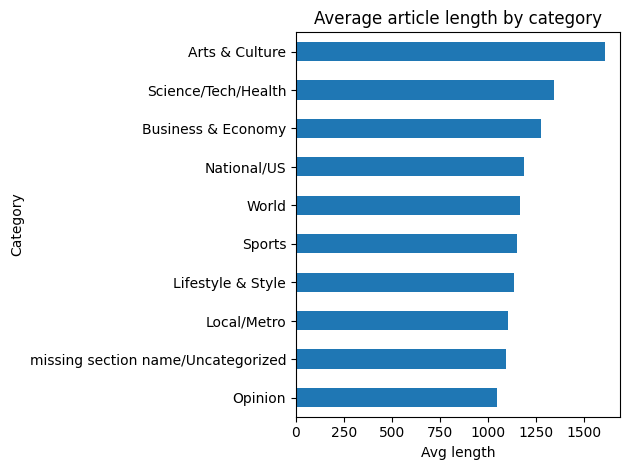

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

cat_len = (
   df_new.groupby("category", dropna=False, observed=False)
         .agg(avg_length=("length","mean"), n=("title","size"))
         .sort_values("avg_length", ascending=False)
)
cat_len["avg_length"] = cat_len["avg_length"].round(1)
print(cat_len)

# barchart
plt.figure(figsize=(9, 5))
cat_len.sort_values("avg_length").plot(kind="barh", y="avg_length", legend=False)
plt.title("Average article length by category")
plt.xlabel("Avg length")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

category                                National/US   World  Local/Metro  \
The New York Times                           1409.8  1204.4       1191.6   
The Philadelphia Inquirer                    1122.4  1109.8        933.9   
Pittsburgh Post-Gazette (Pennsylvania)        898.9   750.3       1057.9   
Chicago Daily Herald                          807.3   780.0        941.8   
Star Tribune (Minneapolis, MN)               1027.6  1035.2        590.8   
USA TODAY                                     859.0     NaN          NaN   
Pittsburgh Post-Gazette                      1075.1   773.0        914.4   
Dayton Daily News (Ohio)                      823.1  1020.1        782.2   
USA Today                                    1485.3     NaN          NaN   
The New York Times Blogs                      667.4   862.8          NaN   

category                                Business & Economy  Opinion  \
The New York Times                                  1453.5   1160.1   
The Philadelphia Inqu

/var/folders/d_/mwgn5kvd6kd55467sgl77bxw0000gn/T/ipykernel_95020/3171187219.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_new.groupby(["publisher_raw","category"], dropna=False)
/var/folders/d_/mwgn5kvd6kd55467sgl77bxw0000gn/T/ipykernel_95020/3171187219.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_len = pub_cat_len.pivot_table(


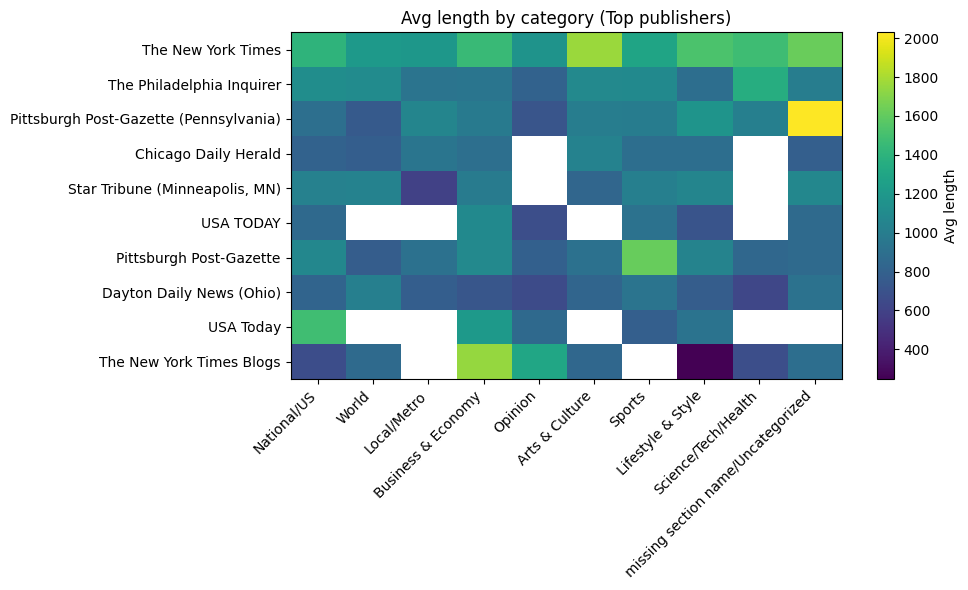

In [84]:
pub_cat_len = (
    df_new.groupby(["publisher_raw","category"], dropna=False)
      .agg(avg_length=("length","mean"), n=("title","size"))
      .reset_index()
)

# pivot table（row：publisher_raw；column：category；value：avg length）
pivot_len = pub_cat_len.pivot_table(
    index="publisher_raw", columns="category", values="avg_length"
).round(1)

# top 10 publisher
top_pub = (df_new["publisher_raw"].value_counts().head(10).index.tolist())
pivot_len_top = pivot_len.loc[pd.Index(top_pub).intersection(pivot_len.index)]
print(pivot_len_top)

plt.figure(figsize=(10, 6))
m = pivot_len_top.values
plt.imshow(m, aspect="auto")
plt.colorbar(label="Avg length")
plt.yticks(ticks=np.arange(len(pivot_len_top.index)), labels=pivot_len_top.index)
plt.xticks(ticks=np.arange(len(pivot_len_top.columns)), labels=pivot_len_top.columns, rotation=45, ha="right")
plt.title("Avg length by category (Top publishers)")
plt.tight_layout()
plt.show()

 ## 4. Analysis on Category & country_flag

In [86]:
# Cross-tab: category × country_flag (counts)
ct = pd.crosstab(df_new["category"], df_new["country_flag"])
print("Raw counts:\n", ct.head(20))

# Row-normalized shares (% within each category)
row_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
print("\nWithin-category % shares:\n", row_pct.head(20))


Raw counts:
 country_flag                        BOTH  FOREIGN_ONLY  NONE  US_ONLY
category                                                             
National/US                         3622           184   381     5885
World                               1932          1093    88      162
Local/Metro                         1582           119   516     3428
Business & Economy                   953            77   116     1289
Opinion                             1971           197   334     3063
Arts & Culture                      4296           555   678     3170
Sports                               412            51    43      394
Lifestyle & Style                   1655           335   395     1443
Science/Tech/Health                   54             7     3       57
missing section name/Uncategorized   184            16    44      364

Within-category % shares:
 country_flag                        BOTH  FOREIGN_ONLY  NONE  US_ONLY
category                                         

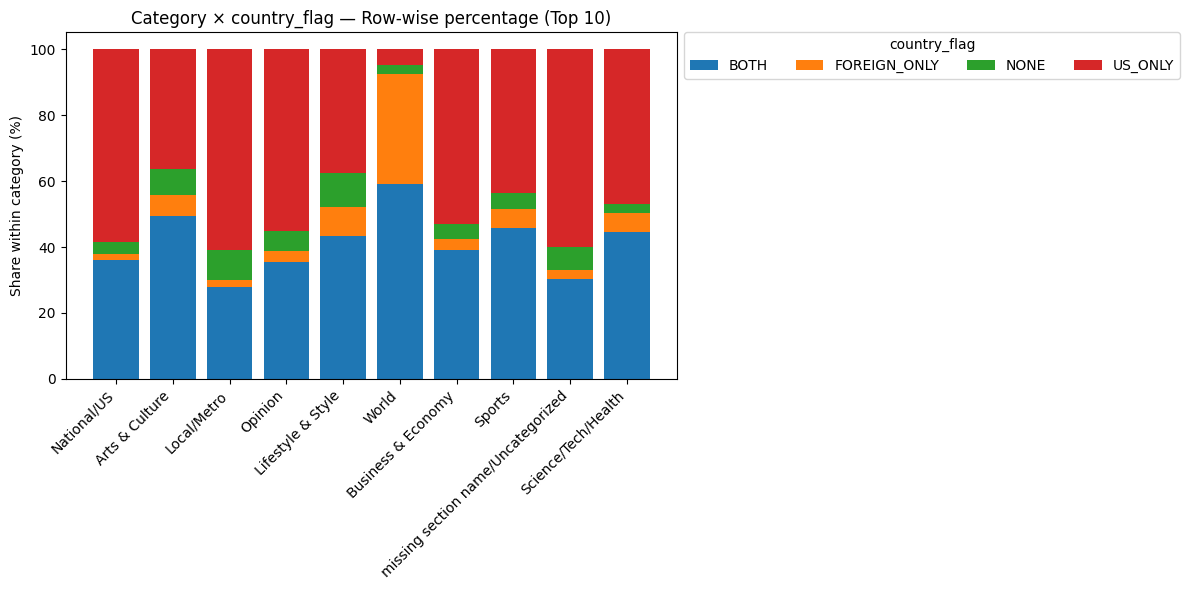

In [87]:
# --- Stacked % bar chart: category × country_flag ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 2) Choose 10 categories by size for readability
TOP_N = 10
cat_order = ct.sum(axis=1).sort_values(ascending=False).index[:TOP_N]
row_pct_top = row_pct.loc[cat_order]

# 3) Plot stacked percentages
plt.figure(figsize=(12, 6))
x = np.arange(len(row_pct_top))
bottom = np.zeros(len(row_pct_top))

for col in row_pct_top.columns:
    vals = row_pct_top[col].values
    plt.bar(x, vals, bottom=bottom, label=col)
    bottom += vals

plt.xticks(x, row_pct_top.index, rotation=45, ha="right")
plt.ylabel("Share within category (%)")
plt.title("Category × country_flag — Row-wise percentage (Top {})".format(TOP_N))
plt.legend(title="country_flag", ncol=4, bbox_to_anchor=(1, 1.02), loc="upper left")
plt.tight_layout()
plt.show()

World is mostly international: BOTH 60.6%, FOREIGN_ONLY 34.3% (US-only just 5.1%).

National/US and Local/Metro are primarily domestic: US_ONLY 60.6% / 67.0%, with notable BOTH spillover (37.6% / 30.7%).